# Auswertung Zelasto Studie

![Bild Depth Touch](images/depth-touch.jpg)

Jupyter Notebook um die in der Zelasto Studie geschriebenen CSV Dateien auf und auszuwerten. 

1. [Studienablauf](#Studienablauf)
1. [Aktuelle Lösung](Aktuelle-Lösung)
1. [Struktur Logfiles](#Struktur-Logfiles)
1. [Werte im Logfile](#Werte-im-Logfile)
1. [Statusabfolge](#Statusabfolge)
1. [Definition der Tiefenebenen](#Definition-der-Tiefenebenen)

## Studienablauf
---

* 6 Probe-Aufgaben (TASK) mit jeweils 2 Wiederholungen (TRIAL)
* 3 Blöcke (BLOCK) mit jeweils
    * 18 Aufgaben (TASK) mit jeweils 5 Wiederholungen (TRIAL)
    * In dem Block wurde immer eine Mapping-Methode (MAPPING_METHOD) genutzt
        * `direct / densening / widening`
    * Variiert wurden in den Aufgaben (TASK) die Anzahl der Tiefenebenen:
        * `6 / 9 / 12 / 15 / 18 / 21`
    * Variiert in den Wiederholungen (TRIALS) wurden die Zielebenen (random)
* Zuordnung Ebene <-> MAPPING_METHOD <-> Tiefe in eigener csv (depthlayers.csv)
* Erfolgs-/Fehlermöglichkeiten:
    * `COMPLETED / FAILED / TERMINATED`

## Aktuelle Lösung
---

* Iterativer / objektorientierter Ansatz (nicht wirklich Data Science strukturiert)
* Gesucht: besser anpassbare, „einfache“ data science Lösung

## Struktur Logfiles
---

`2021-05-11T14:55:08.419Z; INTERACTION; direct;18;14,9,5,1,17;18;1; 0.5099127;0.5482645;-0.449999869;637563489084131200;1;8`

| DateTime (LogServer)     | STATE          | mapping method | Task-No. | Target Layers | Layer-Count | Trial-Idx | PosX             | PosY                                                  | PosZ         | TimeStamp (Server) | InteractionType | CurrentLayer |
| ------------------------ | -------------- | -------------- | -------- | ------------- | ----------- | --------- | ---------------- | ----------------------------------------------------- | ------------ | ------------------ | --------------- | ------------ |
| 2021-05-11T14:55:08.419Z | INTERACTION    | direct         | 18       | 14,9,5,1,17   | 18          | 1         | 0.5099127        | 0.5482645                                             | -0.449999869 | 637563489084131200 | 1               | 8            |
| 2021-05-10T12:14:37.259Z | VIEW           | direct         | 2        | 7,8,1,5,2     | 9           | 0         | TASK_DESCRIPTION |                                                       |              |                    |                 |              |
| 2021-05-10T12:14:37.259Z | TASK           | direct         | 2        | 7,8,1,5,2     | 9           | 0         |                  |                                                       |              |                    |                 |              |
| 2021-05-10T12:13:51.730Z | MAPPING_METHOD | direct         | 1        | 4,5,3,1,2     | 6           | 0         |                  |                                                       |              |                    |                 |              |
| 2021-05-10T12:14:37.264Z | SUBTASK        | direct         | 2        | 7,8,1,5,2     | 9           | 0         | 2                |                                                       |              |                    |                 |              |
| 2021-05-10T12:14:37.265Z | SUBTASK_STATE  | direct         | 2        | 7,8,1,5,2     | 9           | 0         | START            |                                                       |              |                    |                 |              |
| 2021-05-10T12:14:39.587Z | VIEW           | direct         | 2        | 7,8,1,5,2     | 9           | 0         | TASK_VIEW        |                                                       |              |                    |                 |              |
| 2021-05-10T12:14:45.064Z | SUBTASK_STATE  | direct         | 2        | 7,8,1,5,2     | 9           | 0         | HOLD             |                                                       |              |                    |                 |              |
| 2021-05-10T12:14:46.565Z | SUBTASK_STATE  | direct         | 2        | 7,8,1,5,2     | 9           | 0         | COMPLETED        |                                                       |              |                    |                 |              |
| 2021-05-10T12:10:39.115Z | SUBTASK_STATE  | direct         | 1        | 1,5           | 6           | 0         | FAILED           | wrong level approved                                  |              |                    |                 |              |
| 2021-05-10T12:13:38.243Z | SUBTASK_STATE  | densening      | 6        | 3,12          | 14          | 0         | TERMINATED       | switched to other level before hold timeout completed |              |                    |                 |              |

## Werte im Logfile
---

* Tasks:
    * 1-6 (Test)
    * 1-18 (Block 1)
    * 19-36 (Block 2)
    * 37 - 54 (Block 3)

* 3 Blocks for any mapping method

* STATE:
  
    | State Value        | Description                                       | SubTypes           |
    | ------------------ | ------------------------------------------------- | ------------------ |
    | __INTERACTION__    | Trial interaction                                 | -                  |
    | __VIEW__           | switched view (describe Task)                     | TASK_VIEW          |
    |                    | switched view in test runs (describe Task)        | Test Run TASK_VIEW |
    |                    |                                                   | TASK_DESCRIPTION   |
    | __TASK__           |                                                   |                    |
    | __MAPPING_METHOD__ | starting to next large block (mapping method)     |                    |
    | __SUBTASK__        | same as the next: starting to next task           |                    |
    | __SUBTASK_STATE__  | start of the trial after Subtask                  | START              |
    |                    | dwell time in a layer exceeded: hold-timer starts | HOLD               |
    |                    | end of the trial (Success)                        | COMPLETED          |
    |                    | end of the trial (hold failure                    | TERMINATED         |
    |                    | end of the trial (wrong level ?)                  | FAILED             |

* mapping method - describes, how layers are aligned:
    * __direct__ (equivalent distance)
    * __densening__ (larger distance on top, decreasing with depth value)
    * __widening__ (narrower distance on top, increasing with depth value)

* Task-No.
    * running number of tasks

* Target Layers, Trial-Idx
    * array of targets for each layer in current Task
    * trial-Index (zero based) describes target layer for current trial

* Layer-Count
    * number of max layers in Task

* PosX, PosY, PosZ
    * Positions received from Tracking Server
    * PosX / PosY in range [0, 1]
    * PosZ in range [-1, 1] with 0 = on the surface / no interaction, -1 max push, +1 max pull

* Timestamp (Server)
    * timestamp received from Tracking server: miliseconds based unix time stamp

* InteractionType
    * type recognized from server (1 = PUSH)

* current layer
    * layer associated with received depth value

## Statusabfolge
---

1. START (missing on first trial !) OR
    * start of an new task
2. TASK_VIEW / TASK_DESCRIPTION
3. HOLD
4. COMPLETED / TERMINATED / FAILED
   

## Definition der Tiefenebenen
---

__Location:__ `data/depthlayers.csv` [File](data/depthlayers.csv)

`6; direct; 0 | 1 | 2 | 3 | 4 | 5 | 6; 0 | 0.0834 | 0.25 | 0.4167 | 0.5834 | 0.75 | 0.9167 | 1`

| NUM_LAYERS       | MAPPING_METHOD            | DEPTH_LAYER_ID                         | DEPTH_LAYER_BORDER              |
| ---------------- | ------------------------- | -------------------------------------- | ------------------------------- |
| number of layers | mapping method for  block | idx of the depth layer in border array | start depths for each layer idx |

* mapping of layers to depth ranges for better evaluation how "good" a depth layer has been hit


In [48]:
# Imports / global contants

# csv Dateien sind im Verzeichnis ../data zu finden

import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import math
import numpy as np
import seaborn as sns

from pandas.plotting import parallel_coordinates

timeFormat = "%Y-%m-%dT%H:%M:%S.%fZ"

export = "../export/"
export_img = "../export/img/"

path = "../data/"
all_files = glob.glob(path + "/*.csv")

# for debugging: only use first file
# all_files = all_files[9:11]

---

## Vorverarbeitung - Cleaning

* Probe-Aufgaben und eigentliche Studie in verschiedene Dateien
* Ersetzen: Pro Task, muss im ersten Trial  TASK_VIEW mit START getauscht werden
* Spalten benennen (für bessere Adressierung)
* Nebenbedingung/Bonus: sowohl „nur Studie“ / „nur Test“ / „Test und Studie“ zusammen laden  Ordner-Struktur / Namensschema ?
* Lösung/Code dokumentieren (jupyter notebook)


In [61]:
study = []
cleanedStudy = []
columnNames =["DateTime", "State", "mappingMethod", "TaskNo", "TargetLayers", "LayerCount", "TrialIdx", "posX", "posY", "posZ", "TimeStamp", "iteractionType", "currentLayer"]

totalLength = 0

for filename in all_files:
    df = pd.read_csv(filename, sep=";", names = columnNames)
    fn = os.path.basename(filename).split(".")[0]    
    df["Proband"] = fn
    study.append(df)
    totalLength += len(df)
    
print("totallines: " + str(totalLength))

data_complete = pd.concat(study, ignore_index=True)
display (data_complete)

currentLine = 0
swaps = 0

marker = []
marker.append(["Id", "EndInit|START", "EndTests|TASK_VIEW", "SwapLines", "Time_Start", "Time_End", "Shift"])

for testData in study:   
    currentLine += len(testData)
    
    # compare taskNo of next row by shifting series    
    testData["shifted"] = testData["TaskNo"].shift(-1)
    
    # find elements where the taskNo of the next row is 1 and the current row is larger than 1 (that is where the learning tasks end / the whole test restarts )
    markers = testData[(testData["shifted"] == 1) & (testData["TaskNo"] > 1)]
    
    # assert that there are always exactly 2 markers 
    if len(markers) != 2:
        raise Exception("invalid number of markers")
        
    start = markers.index[0]+1
    end = markers.index[1]+1
        
    filteredData = testData.drop(testData.index[end:len(testData)])     
    filteredData = filteredData.drop(filteredData.index[0:start])
    
    filteredData.reset_index(drop=True, inplace=True)
    
    # display(filteredData)  
    
    print("Processed: " + str(currentLine) + " of " +  str(totalLength) + "(" + str(testData["Proband"][0]) + ")")      

    # exchange TASK_VIEW ans START in the first Trial for each Task
   
    startLine = filteredData[(filteredData["TrialIdx"] == 0) & (filteredData["posX"] == " START")]
    taskLine= filteredData[(filteredData["TrialIdx"] == 0) & (filteredData["posX"] == " TASK_VIEW")]
    
    # log Probands where TASK_VIEW and START markers have not an equal count
    # if len(startLine) != len(taskLine):
        # print(f'{testData["Proband"][0]}: {len(startLine)} > {len(taskLine)}')
        
    shift = 0
    
    marker.append([testData["Proband"][0], start, end, "-", filteredData["DateTime"][0], filteredData["DateTime"][len(filteredData)-1], f'{len(taskLine)}/{len(startLine)}'])
    
    # iterate over task lines (start/task swap is not necessary every time) to find START and TASK_VIEW 
    # Swap lines when TASK_VIEW was found
    for i in range(0, len(taskLine)):
        
        # there are some tasks where TASK_View and START are not exchanged
        while (filteredData.iloc[startLine.index[i+shift]]["TaskNo"] != filteredData.iloc[taskLine.index[i]]["TaskNo"]):                       
            shift += 1        
            # print(print(f'{testData["Proband"][0]}: shifted {shift} lines - {startLine.index[i] + start} -> {startLine.index[i+shift] + start}'))
        
        linecopy = filteredData.iloc[startLine.index[i+shift]]["posX"]

        # only exchange the marker - NOT the whole line (preserving the timestamp !)
        filteredData.iat[startLine.index[i+shift], 1] = filteredData.iloc[taskLine.index[i]].at["State"]
        filteredData.iat[startLine.index[i+shift], 7] = filteredData.iloc[taskLine.index[i]].at["posX"]
        filteredData.iat[taskLine.index[i], 7] = linecopy
        
        
        marker.append([testData["Proband"][0], str(startLine.index[i+shift] + start), str(taskLine.index[i] + start), "X" ,filteredData.iloc[startLine.index[i+shift]]["DateTime"], filteredData.iloc[taskLine.index[i]]["DateTime"], shift])


    cleanedStudy.append(filteredData)

    filteredData.to_csv(rf'{export}clean/_{testData["Proband"][0]}.csv')
    
markerframe = pd.DataFrame(data=marker)
markerframe.to_csv(rf'{export}marker.csv', sep= ";")
    
print('finished')

# pd.set_option('display.max_rows', None)

display(markerframe)

# pd.set_option('display.max_rows', 10)

df_cleanedStudy = pd.concat(cleanedStudy)
df_cleanedStudy.to_csv(rf'{export}cleanedStudy.csv', sep= ";")

totallines: 2733080


,DateTime,State,mappingMethod,TaskNo,TargetLayers,LayerCount,TrialIdx,posX,posY,posZ,TimeStamp,iteractionType,currentLayer,Proband
0,2021-05-10T12:08:25.383Z,INTERACTION,direct,1,"1,5",6,0,-,-,-,-,-,-,01
1,2021-05-10T12:08:25.414Z,INTERACTION,direct,1,"1,5",6,0,-,-,-,-,-,-,01
2,2021-05-10T12:08:25.446Z,INTERACTION,direct,1,"1,5",6,0,-,-,-,-,-,-,01
3,2021-05-10T12:08:25.475Z,INTERACTION,direct,1,"1,5",6,0,-,-,-,-,-,-,01
4,2021-05-10T12:08:25.521Z,INTERACTION,direct,1,"1,5",6,0,-,-,-,-,-,-,01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2733075,2021-06-30T12:37:47.525Z,INTERACTION,densening,1,"8,2,7,1,5",9,0,-,-,-,-,-,-,24
2733076,2021-06-30T12:37:47.564Z,INTERACTION,densening,1,"8,2,7,1,5",9,0,-,-,-,-,-,-,24
2733077,2021-06-30T12:37:47.596Z,INTERACTION,densening,1,"8,2,7,1,5",9,0,-,-,-,-,-,-,24
2733078,2021-06-30T12:37:47.639Z,INTERACTION,densening,1,"8,2,7,1,5",9,0,-,-,-,-,-,-,24


Processed: 86106 of 2733080(01)
Processed: 227176 of 2733080(02)
Processed: 339055 of 2733080(03)
Processed: 478493 of 2733080(04)
Processed: 594798 of 2733080(05)
Processed: 720103 of 2733080(06)
Processed: 883086 of 2733080(07)
Processed: 1064088 of 2733080(08)
Processed: 1184333 of 2733080(09)
Processed: 1299948 of 2733080(10)
Processed: 1391165 of 2733080(11)
Processed: 1490464 of 2733080(12)
Processed: 1674368 of 2733080(13)
Processed: 1777237 of 2733080(14)
Processed: 1904586 of 2733080(15)
Processed: 2014642 of 2733080(16)
Processed: 2120240 of 2733080(17)
Processed: 2227439 of 2733080(18)
Processed: 2343047 of 2733080(19)
Processed: 2444664 of 2733080(20)
Processed: 2543798 of 2733080(22)
Processed: 2634877 of 2733080(23)
Processed: 2733080 of 2733080(24)
finished


,0,1,2,3,4,5,6
0,Id,EndInit|START,EndTests|TASK_VIEW,SwapLines,Time_Start,Time_End,Shift
1,01,8616,85411,-,2021-05-10T12:13:51.726Z,2021-05-10T13:01:50.970Z,54/54
2,01,8620,8751,X,2021-05-10T12:13:51.731Z,2021-05-10T12:13:56.584Z,0
3,01,9853,9917,X,2021-05-10T12:14:37.265Z,2021-05-10T12:14:39.587Z,0
4,01,11446,11496,X,2021-05-10T12:15:36.803Z,2021-05-10T12:15:38.697Z,0
...,...,...,...,...,...,...,...
1245,24,91517,91563,X,2021-06-30T12:33:35.699Z,2021-06-30T12:33:37.418Z,0
1246,24,92601,92668,X,2021-06-30T12:34:16.835Z,2021-06-30T12:34:19.275Z,0
1247,24,93795,93884,X,2021-06-30T12:35:01.203Z,2021-06-30T12:35:04.359Z,0
1248,24,95267,95320,X,2021-06-30T12:35:56.333Z,2021-06-30T12:35:58.275Z,0


---

## Globale Statistiken

### Framerate / Versuchsdauer

Duration for each frame by comparing timestamps, in order to find irregularities, errors

Descriptive Statistics for frametimes

---

,DateTime
0,NaN
1,31.0
2,32.0
3,29.0
4,46.0
...,...
2733075,37.0
2733076,39.0
2733077,32.0
2733078,43.0


,DateTime
count,2733079.00000
mean,37.50506
std,8.76651
min,0.00000
25%,32.00000
50%,36.00000
75%,43.00000
max,912.00000


,Proband,TaskNo,TrialIdx,FrameStats
86106,02,1,0,912.0
86374,02,1,0,108.0
227176,03,1,0,180.0
227550,03,1,0,111.0
239713,03,4,0,669.0
239901,03,4,0,206.0
339055,04,1,0,822.0
349352,04,1,0,101.0
478493,05,1,0,481.0
480119,05,1,0,111.0


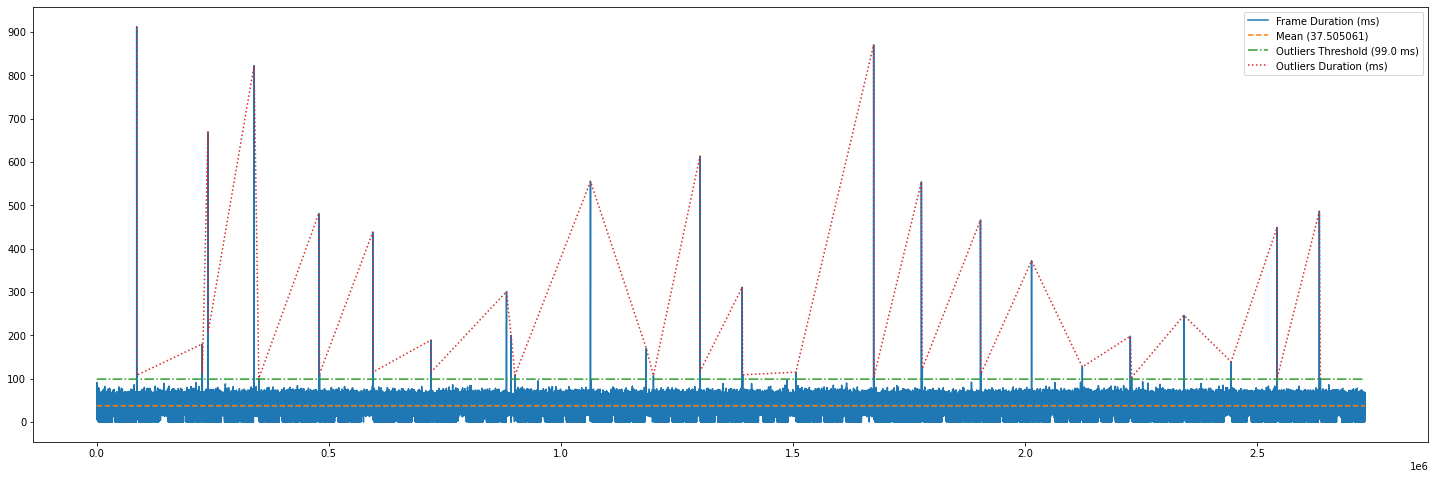

In [49]:
frameStats = pd.DataFrame(pd.to_datetime(data_complete["DateTime"], format=timeFormat).diff().dt.microseconds / 1000.0)

display(frameStats)

desc_stats = frameStats.describe()

display(desc_stats.apply(lambda s: s.apply('{0:.5f}'.format)))

data_complete["FrameStats"] = frameStats

outliers_threshold = 99.0

outliers = data_complete[data_complete["FrameStats"] > outliers_threshold][["Proband", "TaskNo", "TrialIdx", "FrameStats"]]

display(outliers)

y_mean = [desc_stats["DateTime"][1]] * len(frameStats)
outliers_threshold_line = [outliers_threshold] * len(frameStats)

fig,ax = plt.subplots(figsize=(25,8))

ax.plot(frameStats.index, frameStats["DateTime"], label='Frame Duration (ms)')
ax.plot(frameStats.index, y_mean, label=f'Mean ({format(desc_stats["DateTime"][1],"f")})', linestyle='--')
ax.plot(frameStats.index, outliers_threshold_line, label=f'Outliers Threshold ({outliers_threshold} ms)', linestyle='-.')

ax.plot(outliers.index, outliers["FrameStats"], label='Outliers Duration (ms)', linestyle=':')

legend = ax.legend(loc='upper right')

plt.yticks(np.arange(0, desc_stats["DateTime"][7], 100))

fig.savefig(rf'{export_img}frameTimes.png')
fig.savefig(rf'{export_img}frameTimes.svg')

plt.show()

---
## Extraktion

### Trials

#### Ergebnis

| PROBAND | BLOCK | TASK | TRIAL | MAPPING_METHOD | NUM_LAYERS | TARGET | TARGET_RELATIVE | RESULT    |
| ------- | ----- | ---- | ----- | -------------- | ---------- | ------ | --------------- | --------- |
| 1       | 1     | 2    | 5     | direct         | 15         | 7      | 0.46666         | COMPLETED |
| .       | .     | .    | .     | .              | .          | .      | .               | .         |
| .       | .     | .    | .     | .              | .          | .      | .               | .         |

---

In [22]:
#create new Dataframe for the results per Trial and Proband

probands = []

for proband in cleanedStudy:

    start = proband[(proband['posX']  == " START")]
    # remove duplicate labels (keep last)
    start = start.drop_duplicates(['TaskNo', 'TrialIdx'], keep='last')
    
    finish = proband[(proband["posX"] == " COMPLETED") | (proband["posX"] == " FAILED") | (proband["posX"] == " TERMINATED")]
    
    # remove duplicate labels (keep first)
    finish = finish.drop_duplicates(['TaskNo', 'TrialIdx'])
    
    # setting the indices - associate the date sets with each other - nth start <-> nth finish 
    finish["FrameNumber_Start"] = start.index
    start["FrameNumber_Finish"] = finish.index
    
    finish = finish.reset_index()
    start = start.reset_index()
    
    result = pd.DataFrame(start["mappingMethod"])
    result = result.rename(columns= {"mappingMethod": "MappingMethod"})
    
    result["FrameNumber_Start"] = finish["FrameNumber_Start"]
    result["FrameNumber_Finish"] = start["FrameNumber_Finish"]
    result["Block"] = (start["TaskNo"] / 18).apply(np.ceil).astype(int)
    result["Task"] = (start["TaskNo"] - ((result["Block"] - 1) * 18)).astype(int)
    result["Trial"] = start["TrialIdx"].astype(int)
    result["NumLayers"] = start["LayerCount"]    
    result["Target"] = start["TargetLayers"].str.split(",")
    result["Target"] = result.apply(lambda item: item["Target"][item["Trial"]], axis = 1).astype(int)
    result["Target_Relative"] = result["Target"].astype(float) / result["NumLayers"].astype(float)

    result["Result"] = finish["posX"]
    result["Result_Numeric_Completed"] = result["Result"].map({" COMPLETED": 1, " FAILED": 0, " TERMINATED": 0})
    result["Result_Numeric_Terminated"] = result["Result"].map({" COMPLETED": 0, " FAILED": 0, " TERMINATED": 1})
    result["Result_Numeric_Failed"] = result["Result"].map({" COMPLETED": 0, " FAILED": 1, " TERMINATED": 0})
    
    result["Proband"] = start["Proband"]
    
    probands.append(result)

allResults = pd.concat(probands, ignore_index=True)
display(allResults)

allResults.to_csv(rf'{export}results.csv', sep= ";")

display(allResults['Result'].value_counts())

,MappingMethod,FrameNumber_Start,FrameNumber_Finish,Block,Task,Trial,NumLayers,Target,Target_Relative,Result,Result_Numeric_Completed,Result_Numeric_Terminated,Result_Numeric_Failed,Proband
0,direct,135,330,1,1,0,6,4,0.666667,COMPLETED,1,0,0,01
1,direct,413,531,1,1,1,6,5,0.833333,TERMINATED,0,1,0,01
2,direct,603,804,1,1,2,6,3,0.500000,COMPLETED,1,0,0,01
3,direct,870,969,1,1,3,6,1,0.166667,TERMINATED,0,1,0,01
4,direct,1029,1177,1,1,4,6,2,0.333333,COMPLETED,1,0,0,01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6205,widening,89346,89495,3,18,0,6,4,0.666667,COMPLETED,1,0,0,24
6206,widening,89542,89684,3,18,1,6,5,0.833333,COMPLETED,1,0,0,24
6207,widening,89739,89833,3,18,2,6,2,0.333333,TERMINATED,0,1,0,24
6208,widening,89887,90030,3,18,3,6,3,0.500000,COMPLETED,1,0,0,24


 COMPLETED     4349
 TERMINATED    1726
 FAILED         135
Name: Result, dtype: int64

---
#### Dauer

| PROBAND | BLOCK | TASK | TRIAL | MAPPING_METHOD | NUM_LAYERS | TARGET | DURATION |
| ------- | ----- | ---- | ----- | -------------- | ---------- | ------ | ------   |
| 1       | 1     | 2    | 5     | direct         | 15         | 7      | 15.532s  |
| .       | .     | .    | .     | .              | .          | .      | .        |
| .       | .     | .    | .     | .              | .          | .      | .        |

---

,MappingMethod,FrameNumber_Start,FrameNumber_Finish,Block,Task,Trial,NumLayers,Target,Target_Relative,DateTime_Start,DateTime_Finish,Duration,NumFrames,Result,Proband,FrameRate_1
0,direct,135,330,1,1,0,6,4,0.666667,2021-05-10T12:13:56.584Z,2021-05-10T12:14:03.952Z,7.368,195,COMPLETED,01,26.465798
1,direct,413,531,1,1,1,6,5,0.833333,2021-05-10T12:14:07.072Z,2021-05-10T12:14:11.486Z,4.414,118,TERMINATED,01,26.733122
2,direct,603,804,1,1,2,6,3,0.500000,2021-05-10T12:14:14.226Z,2021-05-10T12:14:21.381Z,7.155,201,COMPLETED,01,28.092243
3,direct,870,969,1,1,3,6,1,0.166667,2021-05-10T12:14:23.822Z,2021-05-10T12:14:27.449Z,3.627,99,TERMINATED,01,27.295285
4,direct,1029,1177,1,1,4,6,2,0.333333,2021-05-10T12:14:29.623Z,2021-05-10T12:14:35.139Z,5.516,148,COMPLETED,01,26.831037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6205,widening,89346,89495,3,18,0,6,4,0.666667,2021-06-30T12:36:43.160Z,2021-06-30T12:36:48.797Z,5.637,149,COMPLETED,24,26.432500
6206,widening,89542,89684,3,18,1,6,5,0.833333,2021-06-30T12:36:50.499Z,2021-06-30T12:36:55.824Z,5.325,142,COMPLETED,24,26.666667
6207,widening,89739,89833,3,18,2,6,2,0.333333,2021-06-30T12:36:57.834Z,2021-06-30T12:37:01.272Z,3.438,94,TERMINATED,24,27.341478
6208,widening,89887,90030,3,18,3,6,3,0.500000,2021-06-30T12:37:03.292Z,2021-06-30T12:37:08.759Z,5.467,143,COMPLETED,24,26.156942


,Duration,NumFrames,FrameRate
count,6210.000000,6210.000000,6210.000000
mean,9.276609,246.213205,26.609964
std,13.127383,344.581699,0.623125
min,1.451000,40.000000,17.328951
25%,6.025500,161.000000,26.285908
50%,7.504000,199.000000,26.589875
75%,9.650750,256.000000,26.914084
max,375.574000,9885.000000,52.293007


outliers: fps < 25


,Duration,NumFrames,FrameRate
555,5.172,123,23.781903
556,3.753,86,22.915001
1202,10.565,232,21.959300
2544,10.041,174,17.328951
3424,5.044,118,23.394132
4312,7.779,193,24.810387
5875,10.521,237,22.526376


outliers: fps > 28.2


,Duration,NumFrames,FrameRate
558,2.304,65,28.211806
572,1.539,44,28.589994
1203,3.738,144,38.523274
1745,3.942,113,28.665652
1823,4.388,124,28.258888
2408,5.961,169,28.350948
2545,3.688,105,28.470716
2546,13.315,387,29.064964
2689,1.689,49,29.011249
3092,3.047,86,28.224483


BlockStarts


,MappingMethod,FrameNumber_Start,FrameNumber_Finish,Block,Task,Trial,NumLayers,Target,Target_Relative,DateTime_Start,DateTime_Finish,Duration,NumFrames,Result,Proband,FrameRate_1
0,direct,135,330,1,1,0,6,4,0.666667,2021-05-10T12:13:56.584Z,2021-05-10T12:14:03.952Z,7.368,195,COMPLETED,01,26.465798
90,densening,29857,30045,2,1,0,12,3,0.250000,2021-05-10T12:32:34.956Z,2021-05-10T12:32:42.002Z,7.046,188,COMPLETED,01,26.681805
180,widening,54084,54277,3,1,0,6,4,0.666667,2021-05-10T12:47:41.413Z,2021-05-10T12:47:48.717Z,7.304,193,COMPLETED,01,26.423877
270,direct,195,443,1,1,0,9,5,0.555556,2021-05-11T12:28:09.005Z,2021-05-11T12:28:18.420Z,9.415,248,COMPLETED,02,26.340945
360,widening,56286,56582,2,1,0,6,3,0.500000,2021-05-11T13:03:29.000Z,2021-05-11T13:03:40.318Z,11.318,296,COMPLETED,02,26.153031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5760,widening,27416,27720,2,1,0,9,1,0.111111,2021-06-29T07:36:36.850Z,2021-06-29T07:36:48.450Z,11.600,304,COMPLETED,23,26.206897
5850,densening,56347,56566,3,1,0,18,5,0.277778,2021-06-29T07:54:41.583Z,2021-06-29T07:54:50.040Z,8.457,219,COMPLETED,23,25.895708
5940,densening,128,387,1,1,0,9,8,0.888889,2021-06-30T11:40:35.283Z,2021-06-30T11:40:45.049Z,9.766,259,TERMINATED,24,26.520582
6030,direct,41533,41730,2,1,0,12,11,0.916667,2021-06-30T12:06:43.605Z,2021-06-30T12:06:51.074Z,7.469,197,TERMINATED,24,26.375686


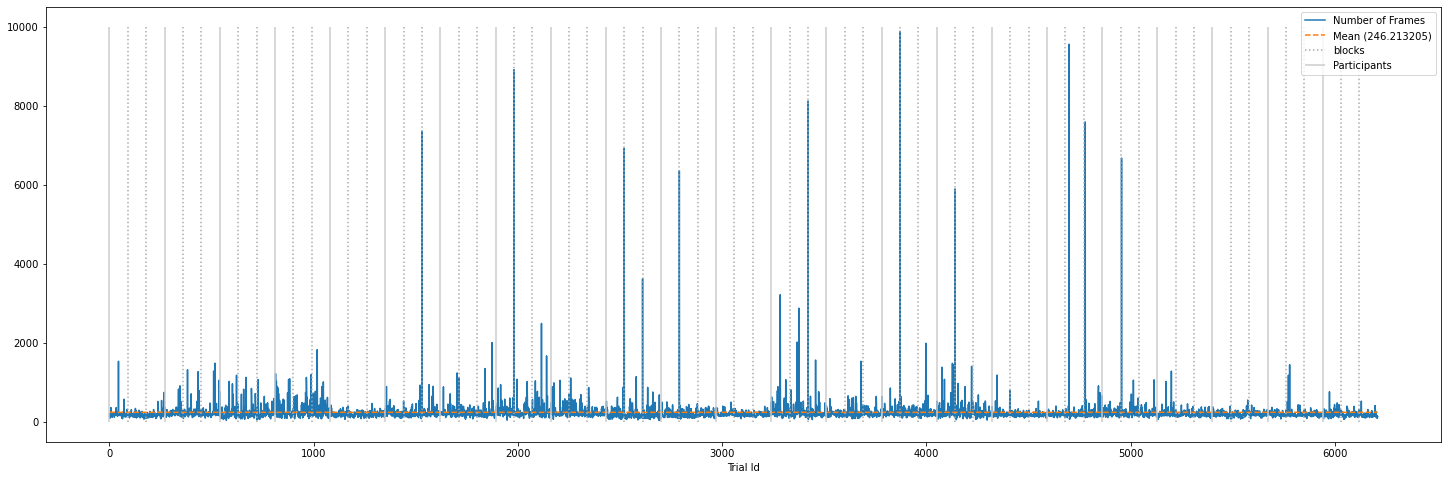

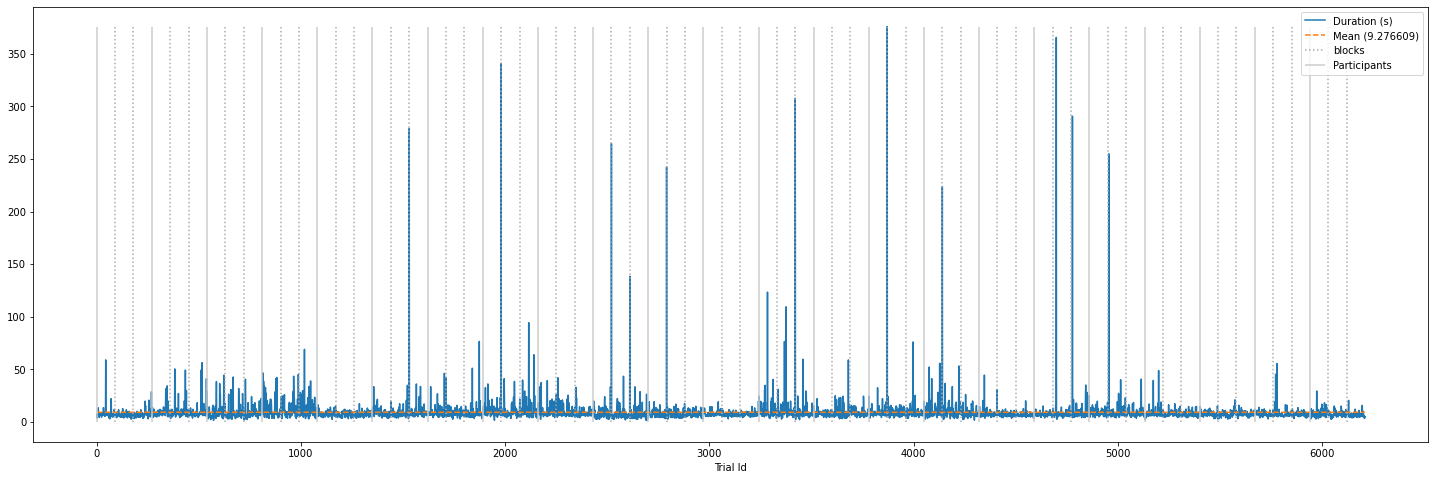

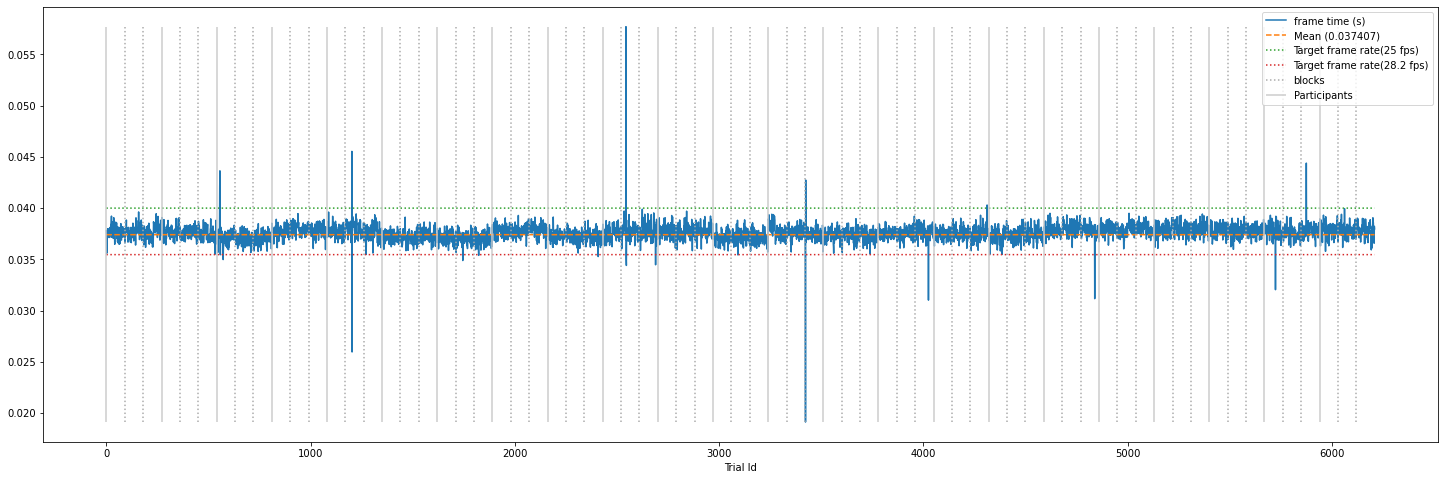

In [50]:
#create new Dataframe for the results per Trial and Proband
# cn_times = ["Proband", "Block", "Task", "Trial", "MappingMethod", "NumLayers", "Target", "Target_Relative", "Duration"]
# end_times = pd.DataFrame(columns = cn_times) 

probands = []

# iterate through all probands
for proband in cleanedStudy:

    start = proband[(proband['posX']  == " START")] 
    finish = proband[(proband["posX"] == " COMPLETED") | (proband["posX"] == " FAILED") | (proband["posX"] == " TERMINATED")]
       
    # remove duplicate labels (keep last)
    start = start.drop_duplicates(['TaskNo', 'TrialIdx'], keep='last')
           
    # remove duplicate labels (keep first)
    finish = finish.drop_duplicates(['TaskNo', 'TrialIdx'], keep='first')
        
    # setting the indices - associate the date sets with each other - nth start <-> nth finish 
    finish["FrameNumber_Start"] = start.index
    start["FrameNumber_Finish"] = finish.index
    
    start["DateTime"] = proband["DateTime"].astype("string")
    finish["DateTime"] = proband["DateTime"].astype("string")
    
    finish = finish.reset_index()
    start = start.reset_index()
    
    result = pd.DataFrame(start["mappingMethod"])
    result = result.rename(columns= {"mappingMethod": "MappingMethod"})
    
    result["FrameNumber_Start"] = finish["FrameNumber_Start"]
    result["FrameNumber_Finish"] = start["FrameNumber_Finish"]
    result["Block"] = (start["TaskNo"] / 18).apply(np.ceil).astype(int)
    result["Task"] = (start["TaskNo"] - ((result["Block"] - 1) * 18)).astype(int)
    result["Trial"] = start["TrialIdx"].astype(int)
    result["NumLayers"] = start["LayerCount"]    
    result["Target"] = start["TargetLayers"].str.split(",")
    result["Target"] = result.apply(lambda item: item["Target"][item["Trial"]], axis = 1).astype(int)
    result["Target_Relative"] = result["Target"].astype(float) / result["NumLayers"].astype(float)

    result["DateTime_Start"] = start["DateTime"]
    result["DateTime_Finish"] = finish["DateTime"]

    result["Duration"] = (pd.to_datetime(finish["DateTime"], format=timeFormat) - pd.to_datetime(start["DateTime"], format=timeFormat)).dt.total_seconds()
    result["NumFrames"] = start["FrameNumber_Finish"]- finish["FrameNumber_Start"]
    result["Result"] = finish["posX"]
    
    result["Proband"] = start["Proband"]

    result["FrameRate_1"] = result["NumFrames"] / result["Duration"]
    
    probands.append(result)

allTimes = pd.concat(probands, ignore_index=True)
display(allTimes)

# descriptive statistics for Duration, FrameRate, Number of Frames per Trial
stats = pd.DataFrame(allTimes["Duration"])
stats["NumFrames"] = allTimes["NumFrames"]
stats["FrameRate"] = stats["NumFrames"] / stats["Duration"]

stats_desc = stats.describe()
display(stats_desc)

target_fps1 = 25
target_fps2 = 28.2

print("outliers: fps < " + str(target_fps1))

outliers1 = stats[1.0 / stats["FrameRate"] > (1.0 / target_fps1)]

display(outliers1)

print("outliers: fps > " + str(target_fps2))

outliers2 = stats[1.0 / stats["FrameRate"] < (1.0 / target_fps2)]

display(outliers2)

print("BlockStarts")

blockStarts = allTimes[(allTimes["Task"] == 1) & (allTimes["Trial"] == 0)]

display(blockStarts)

vlines_x = blockStarts[blockStarts['Block'] > 1].index
vlines_x2 = blockStarts[blockStarts['Block'] == 1].index

y_mean = pd.DataFrame([stats_desc["NumFrames"][1]]*len(allTimes))

fig1,ax1 = plt.subplots(figsize=(25,8))

ax1.plot(allTimes["NumFrames"], label="Number of Frames")
ax1.set_xlabel("Trial Id")
ax1.plot(y_mean, label=f'Mean ({format(stats_desc["NumFrames"][1],"f")})', linestyle='--')

ax1.vlines(x=vlines_x, ymin=0, ymax=10000, color='#AAAAAA', linestyles=':', label='blocks')
ax1.vlines(x=vlines_x2, ymin=0, ymax=10000, color='#CCCCCC', linestyles='-', label='Participants')

legend1 = ax1.legend(loc='upper right')

fig1.savefig(rf'{export_img}numFrames.png')
fig1.savefig(rf'{export_img}numFrames.svg')

y_mean = pd.DataFrame([stats_desc["Duration"][1]]*len(allTimes))

fig2, ax2 = plt.subplots(figsize=(25,8))

ax2.plot(allTimes["Duration"], label="Duration (s)")
ax2.set_xlabel("Trial Id")
ax2.plot(y_mean, label=f'Mean ({format(y_mean[0][0],"f")})', linestyle='--')

ax2.vlines(x=vlines_x, ymin=0, ymax=stats_desc["Duration"]["max"], color='#AAAAAA', linestyles=':', label='blocks')
ax2.vlines(x=vlines_x2, ymin=0, ymax=stats_desc["Duration"]["max"], color='#CCCCCC', linestyles='-', label='Participants')

legend2 = ax2.legend(loc='upper right')

fig2.savefig(rf'{export_img}times.png')
fig2.savefig(rf'{export_img}times.svg')

y_mean = pd.DataFrame([1.0 / allTimes["FrameRate_1"][1]]*len(allTimes))
target_fps_line1 = pd.DataFrame([1.0/target_fps1]*len(allTimes))
target_fps_line2 = pd.DataFrame([1.0/target_fps2]*len(allTimes))

fig3, ax3 = plt.subplots(figsize=(25,8))

ax3.plot(1.0 / stats["FrameRate"], label="frame time (s)")
ax3.set_xlabel("Trial Id")
ax3.plot(y_mean, label=f'Mean ({format(y_mean[0][0],"f")})', linestyle='--')
ax3.plot(target_fps_line1, label=f'Target frame rate({target_fps1} fps)', linestyle=':')
ax3.plot(target_fps_line2, label=f'Target frame rate({target_fps2} fps)', linestyle=':')

ax3.vlines(x=vlines_x, ymin=1.0/stats_desc["FrameRate"]["max"], ymax=1.0/stats_desc["FrameRate"]["min"], color='#AAAAAA', linestyles=':', label='blocks')
ax3.vlines(x=vlines_x2, ymin=1.0/stats_desc["FrameRate"]["max"], ymax=1.0/stats_desc["FrameRate"]["min"], color='#CCCCCC', linestyles='-', label='Participants')

legend3 = ax3.legend(loc='upper right')

fig3.savefig(rf'{export_img}frameTime.png')
fig3.savefig(rf'{export_img}frameTime.svg')

plt.show()

allTimes.to_csv(rf'{export}times.csv', sep= ";")


---
#### Ergebnis (Trial als eigene Spalten)

| PROBAND | BLOCK | TASK | TRIAL0    | ... | TRIALN | MAPPING_METHOD | NUM_LAYERS | TARGET | DURATION |
| ------- | ----- | ---- | --------- | --- | -------| -------------- | ---------- | ------ | ------   |
| 1       | 1     | 2    | COMPLETED | ... | FAILED | direct         | 15         | 7      | 15.532s  |
| .       | .     | .    | .         | ... | .      | .              | .          | .      | .        |
| .       | .     | .    | .         | ... | .      | .              | .          | .      | .        |
---

In [24]:
pivot = allResults.pivot(index=["Proband", "Block", "Task", "MappingMethod", "NumLayers"], columns="Trial", values=["Result", "Result_Numeric_Completed", "Result_Numeric_Failed", "Result_Numeric_Terminated"] )

# print(end_times.columns)
# print(end_times.index)

# display(pivot.columns.names)
# print(pivot.index.names)

# creating the multiIndex... 
m_idx = pd.MultiIndex.from_frame(pivot)

# print(m_idx.get_level_values(0))

pivot['rate_completed'] = (m_idx.get_level_values(5) +  m_idx.get_level_values(6) +  m_idx.get_level_values(7) +  m_idx.get_level_values(8) +  m_idx.get_level_values(9)) / 5
pivot['rate_failed'] = (m_idx.get_level_values(10) +  m_idx.get_level_values(11) +  m_idx.get_level_values(12) +  m_idx.get_level_values(13) +  m_idx.get_level_values(14)) / 5
pivot['rate_terminated'] = (m_idx.get_level_values(15) +  m_idx.get_level_values(16) +  m_idx.get_level_values(17) +  m_idx.get_level_values(18) +  m_idx.get_level_values(19)) / 5

pivot['rate_sum'] = pivot['rate_completed'] + pivot['rate_failed'] + pivot['rate_terminated']

display(pivot)

pivot.to_csv(rf'{export}results_repeat.csv',sep= ";")

num_trials = len(pivot)

print(num_trials)

display(pivot[('Result', 0)].value_counts() / num_trials ) 
display(pivot[('Result', 1)].value_counts() / num_trials )
display(pivot[('Result', 2)].value_counts() / num_trials )
display(pivot[('Result', 3)].value_counts() / num_trials )
display(pivot[('Result', 4)].value_counts() / num_trials )

Result               \
Trial                                                0            1   
Proband Block Task MappingMethod NumLayers                            
01      1     1     direct       6           COMPLETED   TERMINATED   
              2     direct       9           COMPLETED    COMPLETED   
              3     direct       9           COMPLETED    COMPLETED   
              4     direct       15          COMPLETED    COMPLETED   
              5     direct       12          COMPLETED    COMPLETED   
...                                                ...          ...   
24      3     14    widening     9              FAILED   TERMINATED   
              15    widening     12          COMPLETED   TERMINATED   
              16    widening     12          COMPLETED    COMPLETED   
              17    widening     21          COMPLETED    COMPLETED   
              18    widening     6           COMPLETED    COMPLETED   

                                                                      \
Trial                                                 2            3   
Proband Block Task MappingMethod NumLayers                             
01      1     1     direct       6            COMPLETED   TERMINATED   
              2     direct       9           TERMINATED    COMPLETED   
              3     direct       9            COMPLETED   TERMINATED   
              4     direct       15          TERMINATED   TERMINATED   
              5     direct       12           COMPLETED   TERMINATED   
...                                                 ...          ...   
24      3     14    widening     9            COMPLETED    COMPLETED   
              15    widening     12           COMPLETED       FAILED   
              16    widening     12           COMPLETED    COMPLETED   
              17    widening     21          TERMINATED   TERMINATED   
              18    widening     6           TERMINATED    COMPLETED   

                                                         \
Trial                                                 4   
Proband Block Task MappingMethod NumLayers                
01      1     1     direct       6            COMPLETED   
              2     direct       9           TERMINATED   
              3     direct       9            COMPLETED   
              4     direct       15          TERMINATED   
              5     direct       12          TERMINATED   
...                                                 ...   
24      3     14    widening     9            COMPLETED   
              15    widening     12           COMPLETED   
              16    widening     12          TERMINATED   
              17    widening     21              FAILED   
              18    widening     6               FAILED   

                                           Result_Numeric_Completed           \
Trial                                                             0  1  2  3   
Proband Block Task MappingMethod NumLayers                                     
01      1     1     direct       6                                1  0  1  0   
              2     direct       9                                1  1  0  1   
              3     direct       9                                1  1  1  0   
              4     direct       15                               1  1  0  0   
              5     direct       12                               1  1  1  0   
...                                                             ... .. .. ..   
24      3     14    widening     9                                0  0  1  1   
              15    widening     12                               1  0  1  0   
              16    widening     12                               1  1  1  1   
              17    widening     21                               1  1  0  0   
              18    widening     6                                1  1  0  1   

                                               ... Result_Numeric_Failed  \
Trial               

1242


 COMPLETED     0.728663
 TERMINATED    0.245572
 FAILED        0.025765
Name: (Result, 0), dtype: float64

 COMPLETED     0.708535
 TERMINATED    0.270531
 FAILED        0.020934
Name: (Result, 1), dtype: float64

 COMPLETED     0.677939
 TERMINATED    0.304348
 FAILED        0.017713
Name: (Result, 2), dtype: float64

 COMPLETED     0.690016
 TERMINATED    0.293881
 FAILED        0.016103
Name: (Result, 3), dtype: float64

 COMPLETED     0.696457
 TERMINATED    0.275362
 FAILED        0.028180
Name: (Result, 4), dtype: float64

---
#### Dauer (Trial als eigene Spalten)

| PROBAND | BLOCK | TASK | TRIAL0 | ... | TRIALN | MAPPING_METHOD | NUM_LAYERS | TARGET | DURATION |
| ------- | ----- | ---- | ------ | --- | -------| -------------- | ---------- | ------ | ------   |
| 1       | 1     | 2    | 5.532s | ... | 2.546s | direct         | 15         | 7      | 15.532s  |
| .       | .     | .    | .      | ... | .      | .              | .          | .      | .        |
| .       | .     | .    | .      | ... | .      | .              | .          | .      | .        |
---

In [25]:
pivot = allTimes.pivot(index=["Proband", "Block", "Task", "MappingMethod", "NumLayers"], columns="Trial", values="Duration")

# creating the multiIndex... 
m_idx = pd.MultiIndex.from_frame(pivot)

# print(m_idx.get_level_values(0))
    
pivot["Duration_Sum"] = m_idx.get_level_values(0) +  m_idx.get_level_values(1) +  m_idx.get_level_values(2) +  m_idx.get_level_values(3) +  m_idx.get_level_values(4)

display(pivot)

pivot.to_csv(rf'{export}times_repeat.csv',sep= ";")

Trial                                            0       1       2       3  \
Proband Block Task MappingMethod NumLayers                                   
01      1     1     direct       6           7.368   4.414   7.155   3.627   
              2     direct       9           6.978   6.029  13.550  11.628   
              3     direct       9           9.463   7.849   6.402   4.394   
              4     direct       15          8.117   7.910   7.202   7.145   
              5     direct       12          6.645   8.612   8.256   5.049   
...                                            ...     ...     ...     ...   
24      3     14    widening     9           5.444   4.929   5.777   6.530   
              15    widening     12          7.990   5.419   8.240   5.712   
              16    widening     12          7.021  15.856   6.571   6.755   
              17    widening     21         10.186   9.413   4.488   4.400   
              18    widening     6           5.637   5.325   3.438   5.467   

Trial                                           4  Duration_Sum  
Proband Block Task MappingMethod NumLayers                       
01      1     1     direct       6          5.516        28.080  
              2     direct       9          9.832        48.017  
              3     direct       9          8.062        36.170  
              4     direct       15         7.956        38.330  
              5     direct       12         4.624        33.186  
...                                           ...           ...  
24      3     14    widening     9          5.683        28.363  
              15    widening     12         6.656        34.017  
              16    widening     12         5.323        41.526  
              17    widening     21         6.644        35.131  
              18    widening     6          5.088        24.955  

[1242 rows x 6 columns]

---
### Gruppierung nach Ebenenanzahl

#### Ergebnis

| NUM_LAYERS     | COMPLETED | FAILED  | TERMINATED | SUM |
| ---            | ---       | ---     | ---        | --- |
| 5              | 2 / 20%   | 5 / 50% | 3 / 30%    | 10  |
| .              | .         | .       | .          | .   |
| .              | .         | .       | .          | .   |
---

,NumLayers,Completed_Abs,Completed_Rel,Failed_Abs,Failed_Rel,Terminated_Abs,Terminated_Rel,Sum,Sum_Rel
0,6,739,0.714010,13,0.012560,283,0.273430,1035,1.0
1,9,774,0.747826,16,0.015459,245,0.236715,1035,1.0
2,12,732,0.707246,16,0.015459,287,0.277295,1035,1.0
3,15,717,0.692754,26,0.025121,292,0.282126,1035,1.0
4,18,708,0.684058,26,0.025121,301,0.290821,1035,1.0
5,21,679,0.656039,38,0.036715,318,0.307246,1035,1.0


,Completed_Rel,Failed_Rel,Terminated_Rel
count,6.000000,6.000000,6.000000
mean,0.700322,0.021739,0.277939
std,0.030902,0.009058,0.023506
min,0.656039,0.012560,0.236715
25%,0.686232,0.015459,0.274396
50%,0.700000,0.020290,0.279710
75%,0.712319,0.025121,0.288647
max,0.747826,0.036715,0.307246


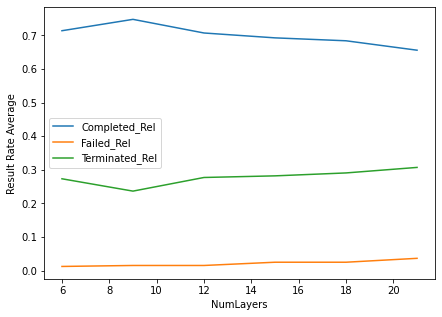

In [51]:
df_resultStat = pd.read_csv(rf'{export}results.csv', sep=";")
# df_resultStat = df_resultStat.iloc[1: , :]

cn_rates = ["NumLayers", "Completed_Abs", "Completed_Rel", "Failed_Abs", "Failed_Rel", "Terminated_Abs", "Terminated_Rel", "Sum"]
df_rates = pd.DataFrame(columns = cn_rates) 

# select all combinations of mappng method / num layers
# allConditions = df_resultStat.drop_duplicates(subset=["MappingMethod", "NumLayers"])[["MappingMethod", "NumLayers"]]

grouped = df_resultStat.groupby(["NumLayers", "Result"]) 

groups = df_resultStat.groupby(["NumLayers"])

for elem in groups:
    df_rates.loc[len(df_rates)] = [elem[0], 0, 0, 0, 0, 0, 0, 0]

count = grouped["Result"].count()

for index, value in count.items():
    rate = df_rates.loc[(df_rates["NumLayers"] == index[0])]
    r_index = rate.index
        
    if index[1] == " COMPLETED":
        compl_sum = int(rate["Completed_Abs"]) + value;
        df_rates.iat[r_index[0], 1] = compl_sum
        
    if index[1] == " FAILED":
        fail_sum = int(rate["Failed_Abs"]) + value;
        df_rates.iat[r_index[0], 3] = fail_sum
        
    if index[1] == " TERMINATED":
        term_sum = int(rate["Terminated_Abs"]) + value;
        df_rates.iat[r_index[0], 5] = term_sum
    
df_rates["Sum"] = pd.to_numeric(df_rates["Completed_Abs"] + df_rates["Failed_Abs"] + df_rates["Terminated_Abs"])
df_rates["Completed_Rel"] = pd.to_numeric(df_rates["Completed_Abs"] / df_rates["Sum"])
df_rates["Failed_Rel"] = pd.to_numeric(df_rates["Failed_Abs"] / df_rates["Sum"])
df_rates["Terminated_Rel"] = pd.to_numeric(df_rates["Terminated_Abs"] / df_rates["Sum"])

df_rates["Sum_Rel"] = pd.to_numeric(df_rates["Completed_Rel"] + df_rates["Failed_Rel"] + df_rates["Terminated_Rel"])
    
display(df_rates.sort_values(by="NumLayers", key=lambda col: col.astype(int)))

ax = df_rates[["NumLayers", "Completed_Rel", "Failed_Rel", "Terminated_Rel"]].plot(x="NumLayers", figsize=(7, 5))
ax.set_ylabel("Result Rate Average")
ax.get_figure().savefig(rf'{export_img}rates_global_layers.png')
ax.get_figure().savefig(rf'{export_img}rates_global_layers.svg')

df_rates.to_csv(rf'{export}rates_global_layers.csv', sep= ";")

df_rates[["Completed_Rel", "Failed_Rel", "Terminated_Rel"]].describe(include="all")

---
#### Dauer

| NUM_LAYERS     | COMPLETED | FAILED  | TERMINATED | SUM        |
| ---            | ---       | ---     | ---        | ---        |
| 5              | 2 / 40s   | 5 / 80s | 3 / 60s    | 10 / 180s  |
| .              | .         | .       | .          | .          |
| .              | .         | .       | .          | .          |
---

,NumLayers,Completed_Num,Completed_Total,Completed_Avg,Failed_Num,Failed_Total,Failed_Avg,Terminated_Num,Terminated_Total,Terminated_Avg,Sum_Num,Sum_Total,All_Avg
0,6,739,5598.762,7.576133,13,78.485,6.037308,283,1369.452,4.839053,1035,7046.699,6.808405
1,9,774,7111.133,9.187510,16,108.995,6.812188,245,1524.931,6.224208,1035,8745.059,8.449332
2,12,732,6413.881,8.762133,16,111.766,6.985375,287,2231.277,7.774484,1035,8756.924,8.460796
3,15,717,6827.991,9.523000,26,334.304,12.857846,292,2873.754,9.841623,1035,10036.049,9.696666
4,18,708,7652.103,10.808055,26,246.834,9.493615,301,3289.363,10.928116,1035,11188.300,10.809952
5,21,679,7787.346,11.468845,38,452.208,11.900211,318,3595.158,11.305528,1035,11834.712,11.434504


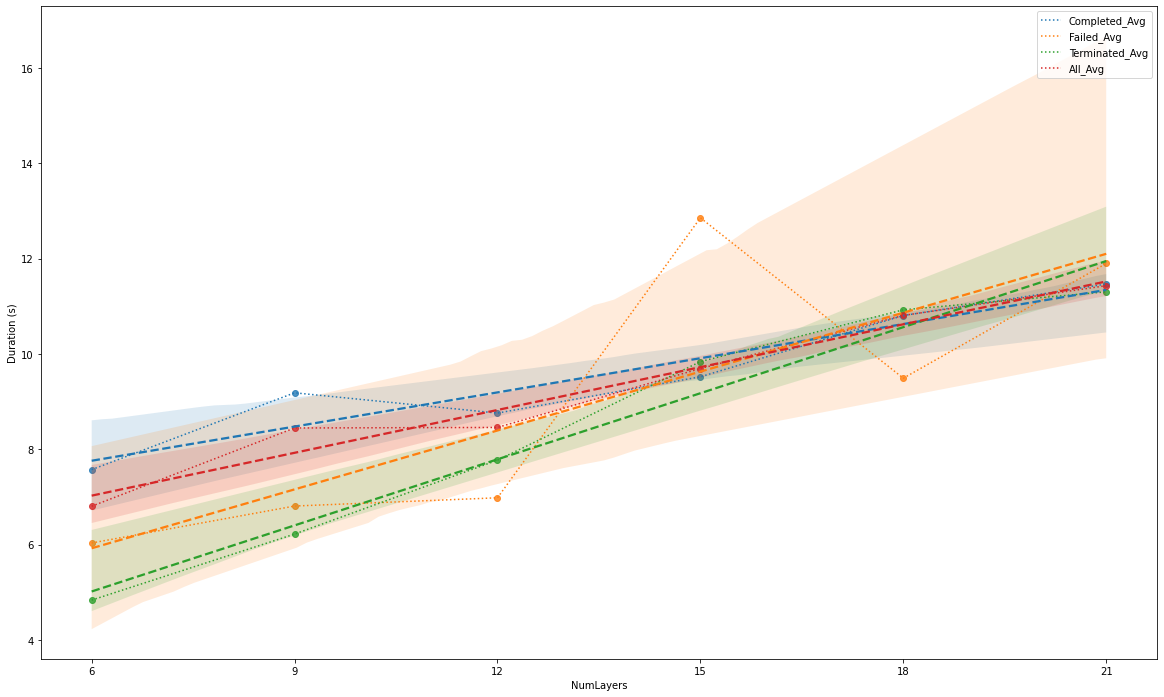

In [52]:
df_timeStat = pd.read_csv(rf'{export}times.csv', sep=";")

df_times = pd.DataFrame() 

# select all combinations of mappng method / num layers

# group all byNumLayers and Result
# compute sum and count for each combination
# pivot results into columns
grouped = df_timeStat.groupby(["NumLayers", "Result"])["Duration"].agg(["sum", "count", "mean"]).reset_index().pivot(index="NumLayers", columns="Result")
m_idx = pd.MultiIndex.from_frame(grouped)

# display(grouped)

# now only for formatting and additional sums: extract multi index values 
df_times["NumLayers"] = grouped.index

df_times["Completed_Num"] = m_idx.get_level_values(3)
df_times["Completed_Total"] = m_idx.get_level_values(0)
df_times["Completed_Avg"] = m_idx.get_level_values(6)

df_times["Failed_Num"] = m_idx.get_level_values(4)
df_times["Failed_Total"] = m_idx.get_level_values(1)
df_times["Failed_Avg"] = m_idx.get_level_values(7)

df_times["Terminated_Num"] = m_idx.get_level_values(5)
df_times["Terminated_Total"] = m_idx.get_level_values(2)
df_times["Terminated_Avg"] = m_idx.get_level_values(8)

df_times["Sum_Num"] = df_times["Completed_Num"] + df_times["Failed_Num"] + df_times["Terminated_Num"]
df_times["Sum_Total"] = df_times["Completed_Total"] + df_times["Failed_Total"] + df_times["Terminated_Total"]
df_times["All_Avg"] = df_times["Sum_Total"] / df_times["Sum_Num"]

display(df_times)

ax = df_times[["NumLayers", "Completed_Avg", "Failed_Avg", "Terminated_Avg", "All_Avg"]].plot(x="NumLayers", figsize=(20, 12), linestyle=":")
ax.set_ylabel("Trial Duration (s)")

# ax.get_figure().savefig(rf'{export}times_global_layers.png')

# seaborn: see https://seaborn.pydata.org/generated/seaborn.regplot.html

ax2 = sns.regplot(x=df_times["NumLayers"], y=df_times["Completed_Avg"], color='C0', line_kws={'ls':'--'})
ax2 = sns.regplot(x=df_times["NumLayers"], y=df_times["Failed_Avg"], color='C1', line_kws={'ls':'--'})
ax2 = sns.regplot(x=df_times["NumLayers"], y=df_times["Terminated_Avg"], color='C2', line_kws={'ls':'--'})
ax2 = sns.regplot(x=df_times["NumLayers"], y=df_times["All_Avg"], color='C3', line_kws={'ls':'--'})

ax2.xaxis.set_major_locator(MultipleLocator(3))
ax2.set_ylabel("Duration (s)")

plt.savefig(rf'{export_img}times_global_layers.png')
plt.savefig(rf'{export_img}times_global_layers.svg')

plt.show()

df_times.to_csv(rf'{export}times_global_layers.csv', sep= ";")


---
### Gruppierung nach Task

#### Ergebnis

| TASK           | COMPLETED | FAILED  | TERMINATED | SUM |
| ---            | ---       | ---     | ---        | --- |
| 1              | 27 / 60%  | 9 / 20% | 9 / 20%    | 45  |
| .              | .         | .       | .          | .   |
| .              | .         | .       | .          | .   |
---

Block Task Result_Numeric_Completed                 Result_Numeric_Failed  \
                                   sum count      mean                   sum   
1      1    1                       79   115  0.686957                     6   
2      1    2                       73   115  0.634783                     2   
3      1    3                       81   115  0.704348                     5   
4      1    4                       73   115  0.634783                     5   
5      1    5                       80   115  0.695652                     4   
6      1    6                       77   115  0.669565                     2   
7      1    7                       84   115  0.730435                     4   
8      1    8                       83   115  0.721739                     2   
9      1    9                       81   115  0.704348                     6   
10     1   10                       80   115  0.695652                     4   
11     1   11                       81   115  0.704348                     1   
12     1   12                       79   115  0.686957                     1   
13     1   13                       75   115  0.652174                     2   
14     1   14                       87   115  0.756522                     4   
15     1   15                       80   115  0.695652                     1   
16     1   16                       71   115  0.617391                     2   
17     1   17                       86   115  0.747826                     2   
18     1   18                       88   115  0.765217                     6   
19     2    1                       80   115  0.695652                     2   
20     2    2                       76   115  0.660870                     3   
21     2    3                       87   115  0.756522                     1   
22     2    4                       78   115  0.678261                     4   
23     2    5                       82   115  0.713043                     0   
24     2    6                       79   115  0.686957                     1   
25     2    7                       68   115  0.591304                     4   
26     2    8                       88   115  0.765217                     2   
27     2    9                       81   115  0.704348                     4   
28     2   10                       79   115  0.686957                     1   
29     2   11                       78   115  0.678261                     2   
30     2   12                       82   115  0.713043                     0   
31     2   13                       87   115  0.756522                     1   
32     2   14                       75   115  0.652174                     0   
33     2   15                       77   115  0.669565                     2   
34     2   16                       78   115  0.678261                     1   
35     2   17                       78   115  0.678261                     0   
36     2   18                       82   115  0.713043                     0   
37     3    1                       72   115  0.626087                     1   
38     3    2                       82   115  0.713043                     3   
39     3    3                       74   115  0.643478                     3   
40     3    4                       86   115  0.747826                     5   
41     3    5                       87   115  0.756522                     2   
42     3    6                       87   115  0.756522                     3   
43     3    7                       79   115  0.686957                     3   
44     3    8                       83   115  0.721739                     6   
45     3    9                       83   115  0.721739                     2   
46     3   10                       86   115  0.747826                     1   
47     3   11                       76   115  0.660870                     1   
48     3   12                       80   115  0.695652                     1   
49 

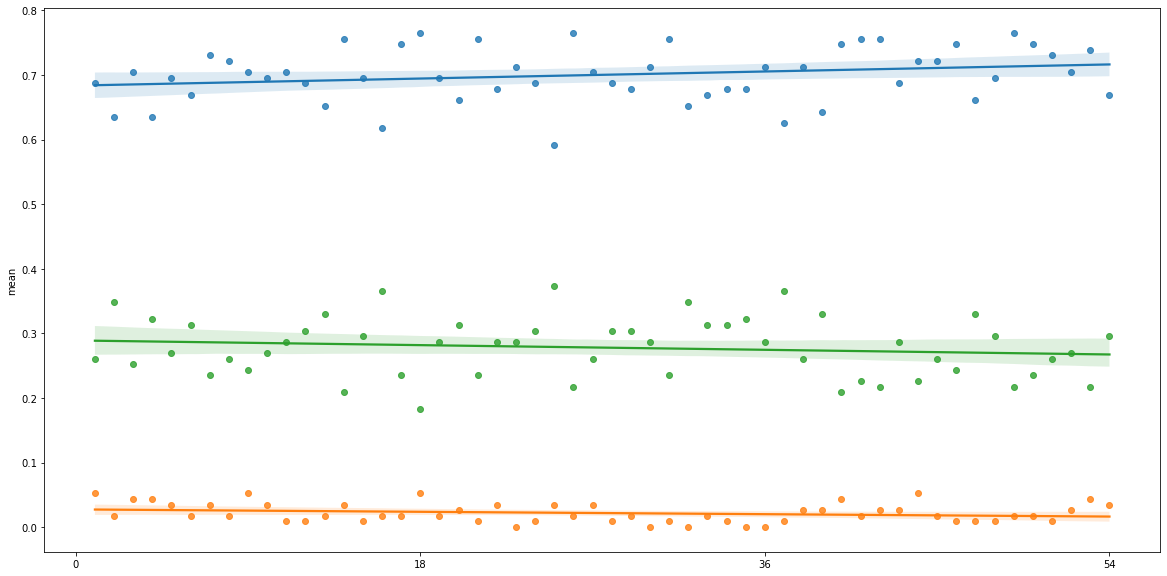

In [53]:
df_timeStat = pd.read_csv(rf'{export}results.csv', sep=";")

df_times = pd.DataFrame() 

# select all combinations of mappng method / num layers

# group all byNumLayers and Result
# compute sum and count for each combination
# pivot results into columns
grouped = df_timeStat.groupby(["Block", "Task"])[["Result_Numeric_Completed", "Result_Numeric_Failed", "Result_Numeric_Terminated"]].agg(["sum", "count", "mean"]).reset_index()
grouped.index = range(1,len(grouped)+1)
# .agg(["sum", "count", "mean"]).reset_index().pivot(index="Trial", columns="Result")
# m_idx = pd.MultiIndex.from_frame(grouped)

display(grouped)

plt.figure(figsize=(20,10))

ax = sns.regplot(x=grouped.index, y=grouped["Result_Numeric_Completed"]["mean"])
ax = sns.regplot(x=grouped.index, y=grouped["Result_Numeric_Failed"]["mean"])
ax = sns.regplot(x=grouped.index, y=grouped["Result_Numeric_Terminated"]["mean"])

ax.xaxis.set_major_locator(MultipleLocator(18))

# ax = grouped["Result_Numeric_Completed"]["mean"].plot()
# ax = grouped["Result_Numeric_Failed"]["mean"].plot()
# ax = grouped["Result_Numeric_Terminated"]["mean"].plot()

plt.savefig(rf'{export_img}results_task.png')
plt.savefig(rf'{export_img}results_task.svg')

grouped.to_csv(rf'{export}results_task.csv')


---
#### Dauer 

| TASK           | COMPLETED | FAILED  | TERMINATED | SUM        |
| ---            | ---       | ---     | ---        | ---        |
| 1              | 35 / 120s | 4 / 80s | 6 / 80s    | 45 / 280s  |
| .              | .         | .       | .          | .          |
| .              | .         | .       | .          | .          |
---

,Block,Task,sum,count,mean
1,1,1,1181.319,115,10.272339
2,1,2,1087.508,115,9.456591
3,1,3,971.700,115,8.449565
4,1,4,1008.022,115,8.765409
5,1,5,967.176,115,8.410226
6,1,6,986.245,115,8.576043
7,1,7,1033.359,115,8.985730
8,1,8,1021.413,115,8.881852
9,1,9,1206.490,115,10.491217
10,1,10,1064.862,115,9.259670


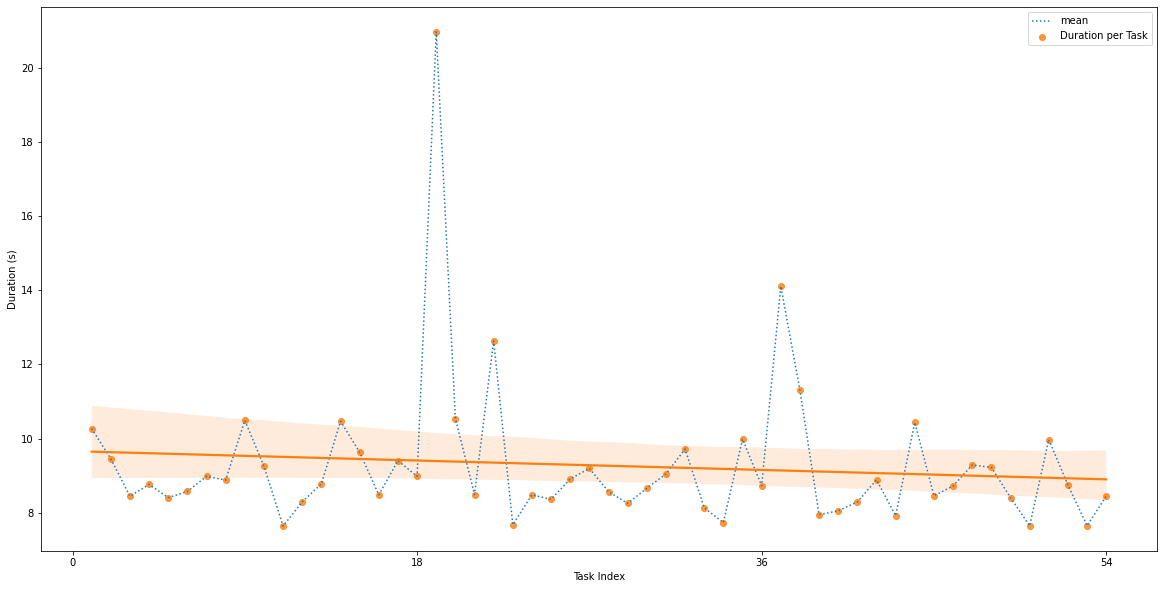

In [54]:
df_timeStat = pd.read_csv(rf'{export}times.csv', sep=";")

df_times = pd.DataFrame() 

# select all combinations of mappng method / num layers

# group all byNumLayers and Result
# compute sum and count for each combination
# pivot results into columns
grouped = df_timeStat.groupby(["Block", "Task"])["Duration"].agg(["sum", "count", "mean"]).reset_index()
grouped.index = range(1,len(grouped)+1)
# .agg(["sum", "count", "mean"]).reset_index().pivot(index="Trial", columns="Result")
# m_idx = pd.MultiIndex.from_frame(grouped)

display(grouped)

# ax = grouped["mean"].plot()
# ax.set_ylabel("Trial Duration (s)")
# ax.get_figure().savefig(rf'{export}times_global_layers.png')

plt.figure(figsize=(20,10))

ax = grouped["mean"].plot(x="NumLayers", linestyle=":")

ax2 = sns.regplot(x=grouped.index, y=grouped["mean"], label="Duration per Task")
ax2.xaxis.set_major_locator(MultipleLocator(18))
ax2.set_ylabel("Duration (s)")
ax2.set_xlabel("Task Index")
legend2 = ax2.legend(loc='upper right')

plt.savefig(rf'{export_img}times_task.png')
plt.savefig(rf'{export_img}times_task.svg')
plt.show()

# ax = grouped["Result_Numeric_Completed"]["mean"].plot()
# ax = grouped["Result_Numeric_Failed"]["mean"].plot()
# ax = grouped["Result_Numeric_Terminated"]["mean"].plot()

grouped.to_csv(rf'{export}times_task.csv')


---
### Gruppierung nach Proband und Ebenenanzahl

#### Ergebnis

| Proband     | NUM_LAYERS     | COMPLETED | FAILED  | TERMINATED | SUM |
| ---         | ---            | ---       | ---     | ---        | --- |
| 0           | 5              | 2 / 20%   | 5 / 50% | 3 / 30%    | 10  |
| .           | .              | .         | .       | .          | .   |
| .           | .              | .         | .       | .          | .   |
---

,Proband,NumLayers,Completed_Abs,Completed_Rel,Failed_Abs,Failed_Rel,Terminated_Abs,Terminated_Rel,Sum,Not_Completed_Abs,Sum_Rel
0,1,6,27,0.6,0,0.0,18,0.4,45,18,1.0
1,1,9,31,0.688889,0,0.0,14,0.311111,45,14,1.0
2,1,12,29,0.644444,1,0.022222,15,0.333333,45,16,1.0
3,1,15,33,0.733333,2,0.044444,10,0.222222,45,12,1.0
4,1,18,31,0.688889,1,0.022222,13,0.288889,45,14,1.0
...,...,...,...,...,...,...,...,...,...,...,...
133,24,9,31,0.688889,4,0.088889,10,0.222222,45,14,1.0
134,24,12,30,0.666667,2,0.044444,13,0.288889,45,15,1.0
135,24,15,27,0.6,4,0.088889,14,0.311111,45,18,1.0
136,24,18,27,0.6,7,0.155556,11,0.244444,45,18,1.0


<Figure size 720x720 with 0 Axes>

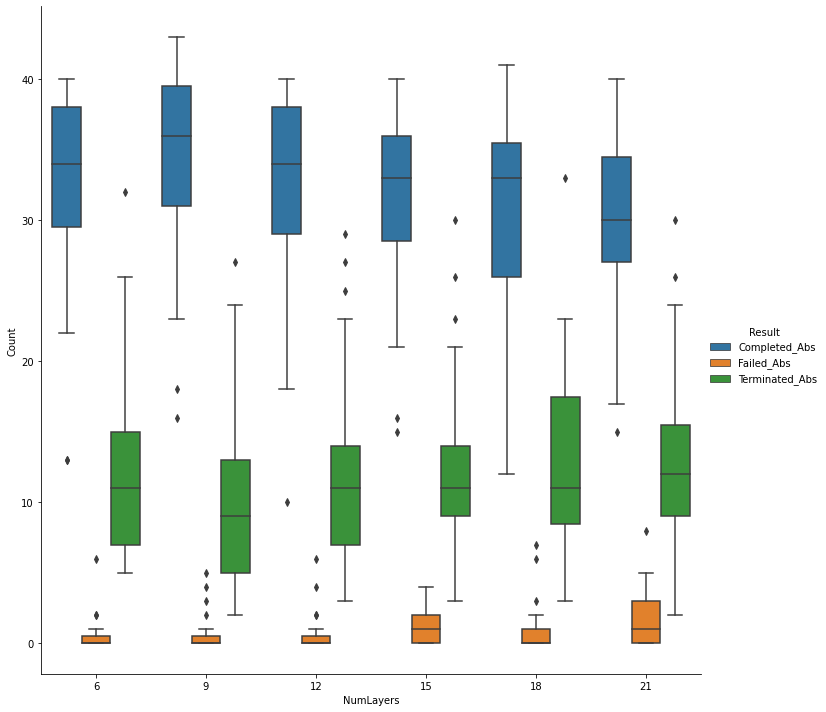

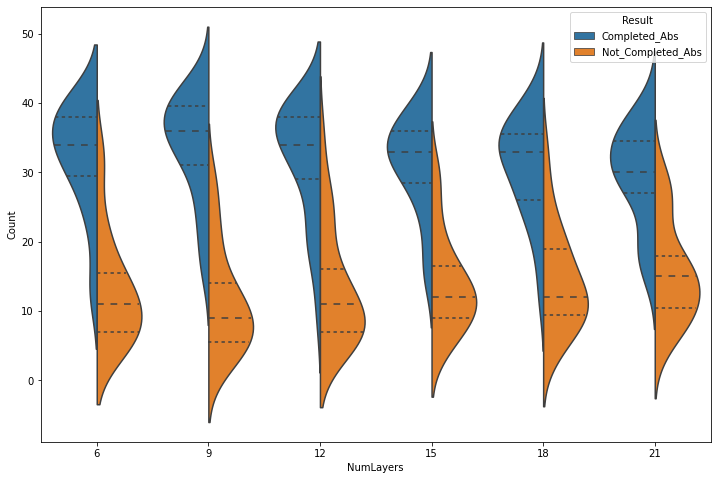

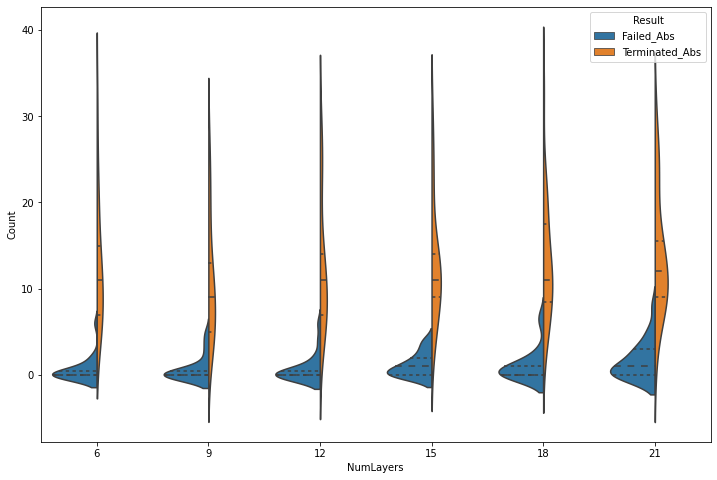

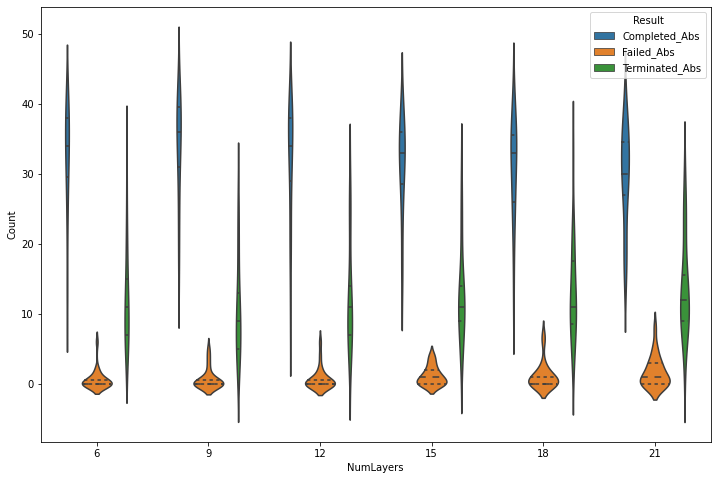

In [55]:
df_resultStat = pd.read_csv(rf'{export}results.csv', sep=";")
# df_resultStat = df_resultStat.iloc[1: , :]

cn_rates = ["Proband", "NumLayers", "Completed_Abs", "Completed_Rel", "Failed_Abs", "Failed_Rel", "Terminated_Abs", "Terminated_Rel", "Sum"]
df_rates = pd.DataFrame(columns = cn_rates) 

# select all combinations of mappng method / num layers
# allConditions = df_resultStat.drop_duplicates(subset=["MappingMethod", "NumLayers"])[["MappingMethod", "NumLayers"]]

grouped = df_resultStat.groupby(["Proband", "NumLayers", "Result"]) 

groups = df_resultStat.groupby(["Proband", "NumLayers"])

for elem in groups:
    df_rates.loc[len(df_rates)] = [elem[0][0], elem[0][1], 0, 0, 0, 0, 0, 0, 0]

    
count = grouped["Result"].count()

for index, value in count.items():
    rate = df_rates.loc[(df_rates["Proband"] == index[0]) & (df_rates["NumLayers"] == index[1])]
    r_index = rate.index
        
    if index[2] == " COMPLETED":
        compl_sum = int(rate["Completed_Abs"]) + value;
        df_rates.iat[r_index[0], 2] = compl_sum
        
    if index[2] == " FAILED":
        fail_sum = int(rate["Failed_Abs"]) + value;
        df_rates.iat[r_index[0], 4] = fail_sum
        
    if index[2] == " TERMINATED":
        term_sum = int(rate["Terminated_Abs"]) + value;
        df_rates.iat[r_index[0], 6] = term_sum
    
df_rates["Sum"] = df_rates["Completed_Abs"] + df_rates["Failed_Abs"] + df_rates["Terminated_Abs"]
df_rates["Completed_Rel"] = df_rates["Completed_Abs"] / df_rates["Sum"]
df_rates["Failed_Rel"] = df_rates["Failed_Abs"] / df_rates["Sum"]
df_rates["Terminated_Rel"] = df_rates["Terminated_Abs"] / df_rates["Sum"]
df_rates["Not_Completed_Abs"] = df_rates["Terminated_Abs"] + df_rates["Failed_Abs"]

df_rates["Sum_Rel"] = df_rates["Completed_Rel"] + df_rates["Failed_Rel"] + df_rates["Terminated_Rel"]
    
display(df_rates.sort_values(by=["Proband", "NumLayers"], key=lambda col: col.astype(int)))

# ax = df_rates[["NumLayers", "Completed_Rel", "Failed_Rel", "Terminated_Rel"]].plot(x="NumLayers", figsize=(10, 10))
# ax.set_ylabel("Result Rate Average")
# ax.get_figure().savefig(rf'{export}rates_subject_layers.png')

df_plot = pd.melt(frame=df_rates, id_vars=["Proband","NumLayers"], value_vars=["Completed_Abs", "Failed_Abs", "Terminated_Abs"], var_name="Result", value_name="Count").reset_index()
df_plot["Count"] = df_plot["Count"] .astype(int) 

df_plot2 = pd.melt(frame=df_rates, id_vars=["Proband","NumLayers"], value_vars=["Completed_Abs", "Not_Completed_Abs"], var_name="Result", value_name="Count").reset_index()
df_plot2["Count"] = df_plot2["Count"] .astype(int) 

df_plot3 = pd.melt(frame=df_rates, id_vars=["Proband","NumLayers"], value_vars=["Failed_Abs", "Terminated_Abs"], var_name="Result", value_name="Count").reset_index()
df_plot3["Count"] = df_plot3["Count"] .astype(int) 

plt.figure(figsize=(10,10))
ax2 = sns.catplot(data = df_plot, x="NumLayers", y="Count", hue="Result", kind="box", height=10)
plt.savefig(rf'{export_img}rates_layers_box.png')
plt.savefig(rf'{export_img}rates_layers_box.svg')
plt.show()

plt.figure(figsize=(12,8))
ax3 = sns.violinplot(data= df_plot2, x="NumLayers", y="Count", hue="Result", split=True, inner="quartile")
plt.savefig(rf'{export_img}rates_layers_violin_completed_notCompleted.png')
plt.savefig(rf'{export_img}rates_layers_violin_completed_notCompleted.svg')
plt.show()

plt.figure(figsize=(12,8))
ax4 = sns.violinplot(data= df_plot3, x="NumLayers", y="Count", hue="Result", split=True, inner="quartile")
plt.savefig(rf'{export_img}rates_layers_violin_failed_terminated.png')
plt.savefig(rf'{export_img}rates_layers_violin_failed_terminated.svg')
plt.show()

plt.figure(figsize=(12,8))
ax5 = sns.violinplot(data= df_plot, x="NumLayers", y="Count", hue="Result", inner="quartile")
plt.savefig(rf'{export_img}rates_layers_violin.png')
plt.savefig(rf'{export_img}rates_layers_violin.svg')
plt.show()

df_rates.to_csv(rf'{export}rates_subject_layers.csv', sep= ";")

---
#### Dauer

| PROBAND | NUM_LAYERS     | COMPLETED | FAILED  | TERMINATED | SUM |
| ---     | ---            | ---       | ---     | ---        | --- |
| 0       | 5              | 2 / 40s   | 5 / 80s | 3 / 60s    | 10  |
| .       | .              | .         | .       | .          | .   |
| .       | .              | .         | .       | .          | .   |
---

,Proband,NumLayers,Completed_Num,Completed_Total,Completed_Avg,Failed_Num,Failed_Total,Failed_Avg,Terminated_Num,Terminated_Total,Terminated_Avg,Sum_Num,Sum_Total,All_Avg
0,1,6,27.0,164.663,6.098630,0.0,0.000,0.000000,18.0,73.467,4.081500,45.0,238.130,5.291778
1,1,9,31.0,210.685,6.796290,0.0,0.000,0.000000,14.0,107.125,7.651786,45.0,317.810,7.062444
2,1,12,29.0,219.664,7.574621,1.0,8.897,8.897000,15.0,83.795,5.586333,45.0,312.356,6.941244
3,1,15,33.0,264.755,8.022879,2.0,23.428,11.714000,10.0,65.496,6.549600,45.0,353.679,7.859533
4,1,18,31.0,247.034,7.968839,1.0,9.593,9.593000,13.0,108.254,8.327231,45.0,364.881,8.108467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,24,9,31.0,221.574,7.147548,4.0,21.061,5.265250,10.0,54.379,5.437900,45.0,297.014,6.600311
134,24,12,30.0,252.464,8.415467,2.0,13.577,6.788500,13.0,87.464,6.728000,45.0,353.505,7.855667
135,24,15,27.0,213.995,7.925741,4.0,30.214,7.553500,14.0,90.025,6.430357,45.0,334.234,7.427422
136,24,18,27.0,230.791,8.547815,7.0,47.262,6.751714,11.0,80.685,7.335000,45.0,358.738,7.971956


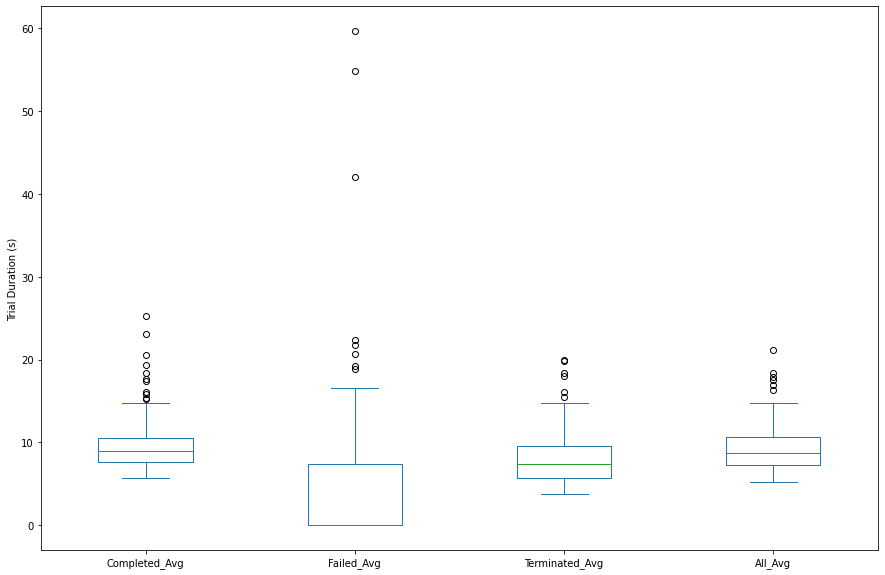

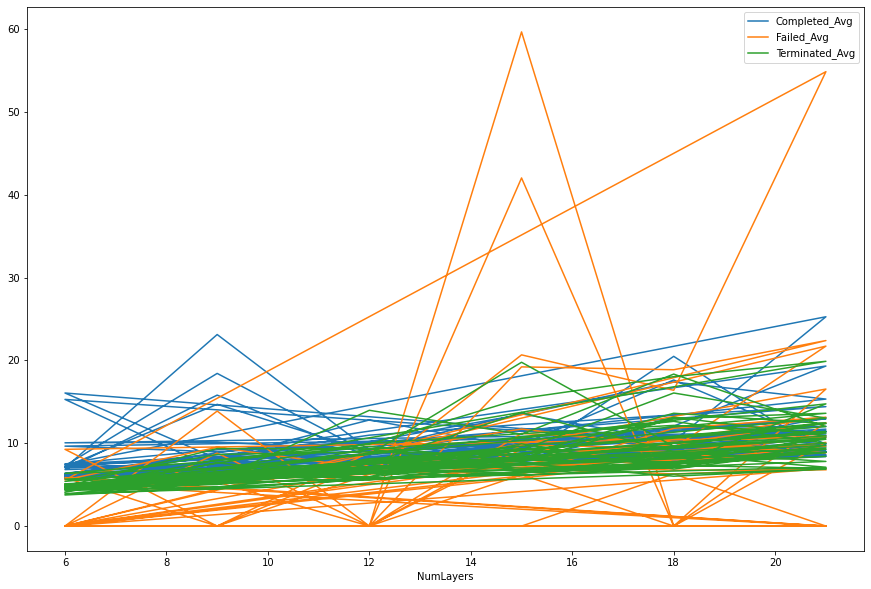

In [56]:
df_timeStat = pd.read_csv(rf'{export}times.csv', sep=";")

df_times = pd.DataFrame() 

# select all combinations of mappng method / num layers

# group all byNumLayers and Result
# compute sum and count for each combination
# pivot results into columns
# flatten groups in between by reset_index
grouped = df_timeStat.groupby(["Proband", "NumLayers", "Result"])["Duration"].agg(["sum", "count", "mean"]).reset_index().pivot(index=["Proband", "NumLayers"], columns="Result")# .reset_index()
m_idx = pd.MultiIndex.from_frame(grouped)

# save index before flattening
df_times["Proband"] = grouped.index.get_level_values(0)
df_times["NumLayers"] = grouped.index.get_level_values(1)

grouped = grouped.reset_index()

# now only for formatting and additional sums: extract multi index values 
df_times["Completed_Num"] = m_idx.get_level_values(3).fillna(0)
df_times["Completed_Total"] = m_idx.get_level_values(0).fillna(0)
df_times["Completed_Avg"] = m_idx.get_level_values(6).fillna(0)

df_times["Failed_Num"] = m_idx.get_level_values(4).fillna(0)
df_times["Failed_Total"] = m_idx.get_level_values(1).fillna(0)
df_times["Failed_Avg"] = m_idx.get_level_values(7).fillna(0)

df_times["Terminated_Num"] = m_idx.get_level_values(5).fillna(0)
df_times["Terminated_Total"] = m_idx.get_level_values(2).fillna(0)
df_times["Terminated_Avg"] = m_idx.get_level_values(8).fillna(0)

df_times["Sum_Num"] = df_times["Completed_Num"] + df_times["Failed_Num"] + df_times["Terminated_Num"]
df_times["Sum_Total"] = df_times["Completed_Total"] + df_times["Failed_Total"] + df_times["Terminated_Total"]
df_times["All_Avg"] = df_times["Sum_Total"] / df_times["Sum_Num"]

display(df_times)

ax = df_times[["Completed_Avg", "Failed_Avg", "Terminated_Avg", "All_Avg"]].plot.box(figsize=(15, 10))
ax.set_ylabel("Trial Duration (s)")
ax.get_figure().savefig(rf'{export_img}times_subject_layers_box.png')
ax.get_figure().savefig(rf'{export_img}times_subject_layers_box.svg')

ax = df_times[["NumLayers", "Completed_Avg", "Failed_Avg", "Terminated_Avg"]].plot(x="NumLayers", figsize=(15, 10))

df_times.to_csv(rf'{export}times_subject_layers.csv', sep= ";")

---
### Gruppierung nach Mapping Methode und Ebenenanzahl

#### Ergebnis

| MAPPING_METHOD | NUM_LAYERS | COMPLETED | FAILED  | TERMINATED | SUM |
| ---            | ---        | ---       | ---     | ---        | --- |
| direct         | 5          | 2 / 20%   | 5 / 50% | 3 / 30%    | 10  |
| .              | .          | .         | .       | .          | .   |
| .              | .          | .         | .       | .          | .   |
---

,MappingMethod,NumLayers,Completed_Abs,Completed_Rel,Failed_Abs,Failed_Rel,Terminated_Abs,Terminated_Rel,Sum,Sum_Rel
0,densening,6,254,0.736232,3,0.008696,88,0.255072,345,1.0
1,densening,9,275,0.797101,6,0.017391,64,0.185507,345,1.0
2,densening,12,261,0.756522,2,0.005797,82,0.237681,345,1.0
3,densening,15,261,0.756522,2,0.005797,82,0.237681,345,1.0
4,densening,18,263,0.762319,4,0.011594,78,0.226087,345,1.0
5,densening,21,239,0.692754,5,0.014493,101,0.292754,345,1.0
6,direct,6,252,0.730435,2,0.005797,91,0.263768,345,1.0
7,direct,9,277,0.802899,3,0.008696,65,0.188406,345,1.0
8,direct,12,257,0.744928,4,0.011594,84,0.243478,345,1.0
9,direct,15,253,0.733333,8,0.023188,84,0.243478,345,1.0


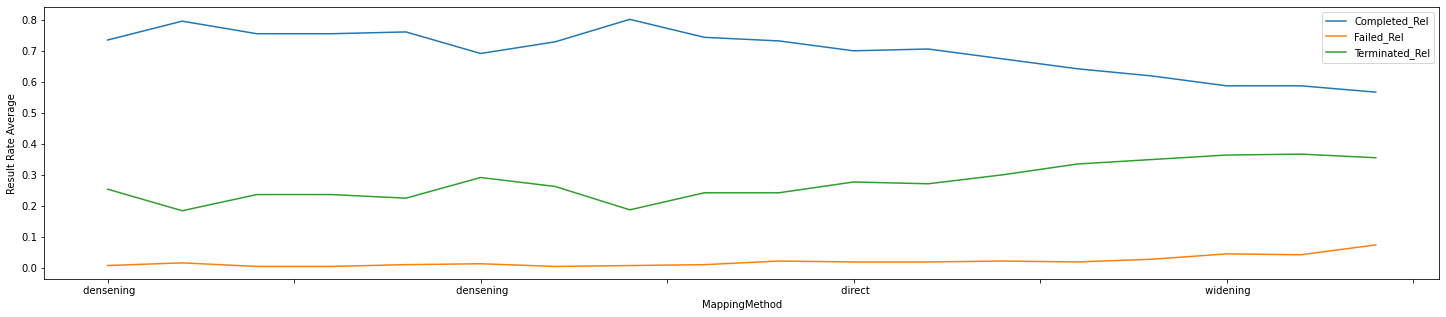

In [57]:
df_resultStat = pd.read_csv(rf'{export}results.csv', sep=";")
#df_resultStat = df_resultStat.iloc[0: , :]

cn_rates = ["MappingMethod", "NumLayers", "Completed_Abs", "Completed_Rel", "Failed_Abs", "Failed_Rel", "Terminated_Abs", "Terminated_Rel", "Sum"]
df_rates = pd.DataFrame(columns = cn_rates) 

# select all combinations of mappng method / num layers
# allConditions = df_resultStat.drop_duplicates(subset=["MappingMethod", "NumLayers"])[["MappingMethod", "NumLayers"]]

grouped = df_resultStat.groupby(["MappingMethod", "NumLayers", "Result"]) 

groups = df_resultStat.groupby(["MappingMethod", "NumLayers"])

for elem in groups:
    df_rates.loc[len(df_rates)] = [elem[0][0], elem[0][1], 0, 0, 0, 0, 0, 0, 0]
    
count = grouped["Result"].count()

for index, value in count.items():
    rate = df_rates.loc[(df_rates["MappingMethod"] == index[0]) & (df_rates["NumLayers"] == index[1])]
    r_index = rate.index
        
    if index[2] == " COMPLETED":
        compl_sum = int(rate["Completed_Abs"]) + value;
        df_rates.iat[r_index[0], 2] = compl_sum
        
    elif index[2] == " FAILED":
        fail_sum = int(rate["Failed_Abs"]) + value;
        df_rates.iat[r_index[0], 4] = fail_sum
        
    elif index[2] == " TERMINATED":
        term_sum = int(rate["Terminated_Abs"]) + value;
        df_rates.iat[r_index[0], 6] = term_sum
        
    else:
        print(index[2])
    
df_rates["Sum"] = df_rates["Completed_Abs"] + df_rates["Failed_Abs"] + df_rates["Terminated_Abs"]
df_rates["Completed_Rel"] = df_rates["Completed_Abs"] / df_rates["Sum"]
df_rates["Failed_Rel"] = df_rates["Failed_Abs"] / df_rates["Sum"]
df_rates["Terminated_Rel"] = df_rates["Terminated_Abs"] / df_rates["Sum"]

df_rates["Sum_Rel"] = df_rates["Completed_Rel"] + df_rates["Failed_Rel"] + df_rates["Terminated_Rel"]
    
display(df_rates.sort_values(by=["MappingMethod", "NumLayers"]))

ax = df_rates[["MappingMethod", "Completed_Rel", "Failed_Rel", "Terminated_Rel"]].plot(x="MappingMethod", figsize=(25, 5))
ax.set_ylabel("Result Rate Average")
ax.get_figure().savefig(rf'{export_img}rates_global_mapping_layers.png')
ax.get_figure().savefig(rf'{export_img}rates_global_mapping_layers.svg')

df_rates.to_csv(rf'{export}rates_global_mapping_layers.csv', sep= ";")

---
#### Dauer

| MAPPING_METHOD | NUM_LAYERS     | COMPLETED | FAILED  | TERMINATED | SUM |
| ---            | ---            | ---       | ---     | ---        | --- |
| direct         | 5              | 2 / 40s   | 5 / 80s | 3 / 60s    | 10  |
| .              | .              | .         | .       | .          | .   |
| .                   | .                  | .            | .          | .             | .     |
---

,MappingMethod,NumLayers,Completed_Num,Completed_Total,Completed_Avg,Failed_Num,Failed_Total,Failed_Avg,Terminated_Num,Terminated_Total,Terminated_Avg,Sum_Num,Sum_Total,All_Avg
0,densening,6,254,2126.898,8.373614,3,20.797,6.932333,88,456.641,5.189102,345,2604.336,7.548800
1,densening,9,275,2500.071,9.091167,6,36.819,6.136500,64,420.079,6.563734,345,2956.969,8.570925
2,densening,12,261,2363.617,9.056004,2,11.346,5.673000,82,645.734,7.874805,345,3020.697,8.755643
3,densening,15,261,2508.066,9.609448,2,48.667,24.333500,82,723.889,8.827915,345,3280.622,9.509049
4,densening,18,263,2916.524,11.089445,4,25.603,6.400750,78,855.137,10.963295,345,3797.264,11.006562
5,densening,21,239,2526.930,10.572929,5,66.178,13.235600,101,1024.928,10.147802,345,3618.036,10.487061
6,direct,6,252,1836.313,7.286956,2,9.607,4.803500,91,457.194,5.024110,345,2303.114,6.675693
7,direct,9,277,2586.452,9.337372,3,19.595,6.531667,65,371.531,5.715862,345,2977.578,8.630661
8,direct,12,257,2135.795,8.310486,4,27.983,6.995750,84,611.641,7.281440,345,2775.419,8.044693
9,direct,15,253,2425.901,9.588542,8,107.961,13.495125,84,977.268,11.634143,345,3511.130,10.177188


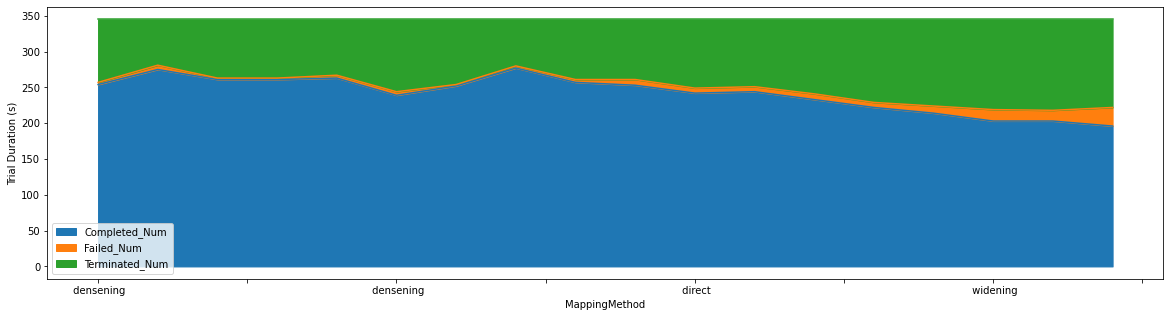

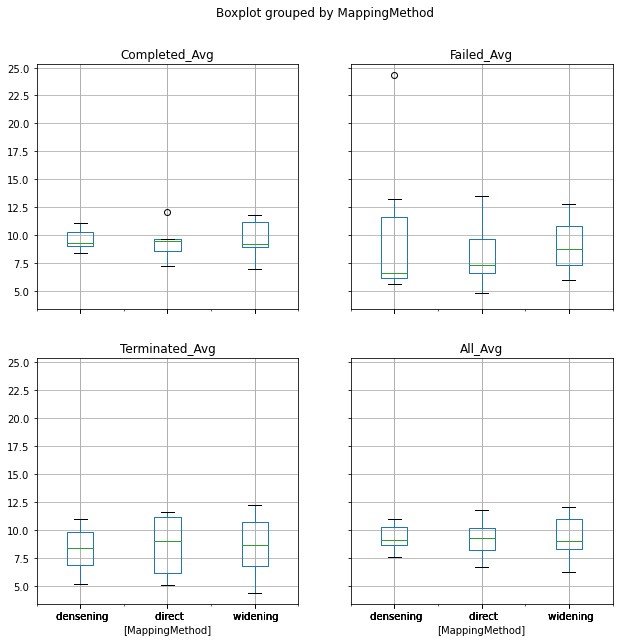

In [60]:
df_timeStat = pd.read_csv(rf'{export}times.csv', sep=";")

df_times = pd.DataFrame() 

# select all combinations of mappng method / num layers

# group all byNumLayers and Result
# compute sum and count for each combination
# pivot results into columns
grouped = df_timeStat.groupby(["MappingMethod", "NumLayers", "Result"])["Duration"].agg(["sum", "count", "mean"]).reset_index().pivot(index=["MappingMethod", "NumLayers"], columns="Result")
m_idx = pd.MultiIndex.from_frame(grouped)

# save index before flattening
df_times["MappingMethod"] = grouped.index.get_level_values(0)
df_times["NumLayers"] = grouped.index.get_level_values(1)

grouped = grouped.reset_index()

# now only for formatting and additional sums: extract multi index values 
df_times["Completed_Num"] = m_idx.get_level_values(3)
df_times["Completed_Total"] = m_idx.get_level_values(0)
df_times["Completed_Avg"] = m_idx.get_level_values(6)

df_times["Failed_Num"] = m_idx.get_level_values(4)
df_times["Failed_Total"] = m_idx.get_level_values(1)
df_times["Failed_Avg"] = m_idx.get_level_values(7)

df_times["Terminated_Num"] = m_idx.get_level_values(5)
df_times["Terminated_Total"] = m_idx.get_level_values(2)
df_times["Terminated_Avg"] = m_idx.get_level_values(8)

df_times["Sum_Num"] = df_times["Completed_Num"] + df_times["Failed_Num"] + df_times["Terminated_Num"]
df_times["Sum_Total"] = df_times["Completed_Total"] + df_times["Failed_Total"] + df_times["Terminated_Total"]
df_times["All_Avg"] = df_times["Sum_Total"] / df_times["Sum_Num"]

display(df_times)

ax = df_times[["MappingMethod", "Completed_Num", "Failed_Num", "Terminated_Num"]].plot.area(x="MappingMethod", figsize=(20, 5))
ax.set_ylabel("Trial Duration (s)")
ax.get_figure().savefig(rf'{export_img}times_global_mapping_layers_area.png')
ax.get_figure().savefig(rf'{export_img}times_global_mapping_layers_area.svg')

ax = df_times[["NumLayers", "MappingMethod", "Completed_Avg", "Failed_Avg", "Terminated_Avg", "All_Avg"]].boxplot(column=["Completed_Avg", "Failed_Avg", "Terminated_Avg", "All_Avg"], by=["MappingMethod"], figsize=(10, 10))

plt.savefig(rf'{export_img}times_global_mapping_layers_box.png')
plt.savefig(rf'{export_img}times_global_mapping_layers_box.svg')

df_times.to_csv(rf'{export}times_global_mapping_layers.csv', sep= ";")

---
### Gruppierung nach Proband, Ebenenanzahl und mapping methode

#### Ergebnis

| Proband | MAPPING_METHOD | NUM_LAYERS | COMPLETED | FAILED  | TERMINATED | SUM |
| ---     | ---            | ---        | ---       | ---     | ---        | --- |
| 0       | direct         | 5          | 2 / 20%   | 5 / 50% | 3 / 30%    | 10  |
| .       | .              | .          | .         | .       | .          | .   |
| .       | .              | .          | .         | .       | .          | .   |
---

In [34]:
df_resultStat = pd.read_csv(rf'{export}results.csv', sep=";")
# df_resultStat = df_resultStat.iloc[1: , :]

cn_rates = ["Proband", "MappingMethod", "NumLayers", "Completed_Abs", "Completed_Rel", "Failed_Abs", "Failed_Rel", "Terminated_Abs", "Terminated_Rel", "Sum"]
df_rates = pd.DataFrame(columns = cn_rates) 

# select all combinations of mappng method / num layers
# allConditions = df_resultStat.drop_duplicates(subset=["MappingMethod", "NumLayers"])[["MappingMethod", "NumLayers"]]

grouped = df_resultStat.groupby(["Proband", "MappingMethod", "NumLayers", "Result"]) 

groups = df_resultStat.groupby(["Proband", "MappingMethod", "NumLayers"])

for elem in groups:
    df_rates.loc[len(df_rates)] = [elem[0][0], elem[0][1], elem[0][2], 0, 0, 0, 0, 0, 0, 0]

count = grouped["Result"].count()

for index, value in count.items():
    rate = df_rates.loc[(df_rates["Proband"] == index[0]) & (df_rates["MappingMethod"] == index[1]) & (df_rates["NumLayers"] == index[2])]
    r_index = rate.index
        
    if index[3] == " COMPLETED":
        compl_sum = int(rate["Completed_Abs"]) + value;
        df_rates.iat[r_index[0], 3] = compl_sum
        
    if index[3] == " FAILED":
        fail_sum = int(rate["Failed_Abs"]) + value;
        df_rates.iat[r_index[0], 5] = fail_sum
        
    if index[3] == " TERMINATED":
        term_sum = int(rate["Terminated_Abs"]) + value;
        df_rates.iat[r_index[0], 7] = term_sum
        
    
df_rates["Sum"] = df_rates["Completed_Abs"] + df_rates["Failed_Abs"] + df_rates["Terminated_Abs"]
df_rates["Completed_Rel"] = df_rates["Completed_Abs"] / df_rates["Sum"]
df_rates["Failed_Rel"] = df_rates["Failed_Abs"] / df_rates["Sum"]
df_rates["Terminated_Rel"] = df_rates["Terminated_Abs"] / df_rates["Sum"]

df_rates["Sum_Rel"] = df_rates["Completed_Rel"] + df_rates["Failed_Rel"] + df_rates["Terminated_Rel"]
    
display(df_rates.sort_values(by=["Proband", "MappingMethod", "NumLayers"]))

df_rates.to_csv(rf'{export}rates_subject_mapping_layers.csv', sep= ";")

,Proband,MappingMethod,NumLayers,Completed_Abs,Completed_Rel,Failed_Abs,Failed_Rel,Terminated_Abs,Terminated_Rel,Sum,Sum_Rel
0,1,densening,6,9,0.6,0,0.0,6,0.4,15,1.0
1,1,densening,9,11,0.733333,0,0.0,4,0.266667,15,1.0
2,1,densening,12,10,0.666667,0,0.0,5,0.333333,15,1.0
3,1,densening,15,14,0.933333,0,0.0,1,0.066667,15,1.0
4,1,densening,18,10,0.666667,0,0.0,5,0.333333,15,1.0
...,...,...,...,...,...,...,...,...,...,...,...
409,24,widening,9,8,0.533333,2,0.133333,5,0.333333,15,1.0
410,24,widening,12,10,0.666667,1,0.066667,4,0.266667,15,1.0
411,24,widening,15,8,0.533333,0,0.0,7,0.466667,15,1.0
412,24,widening,18,7,0.466667,4,0.266667,4,0.266667,15,1.0


---
#### Dauer

| Proband | MAPPING_METHOD | NUM_LAYERS | COMPLETED | FAILED  | TERMINATED | SUM |
| ---     | ---            | ---        | ---       | ---     | ---        | --- |
| 0       | direct         | 5          | 2 / 20s   | 5 / 50s | 3 / 30s    | 100s|
| .       | .              | .          | .         | .       | .          | .   |
| .       | .              | .          | .         | .       | .          | .   |  
---

In [35]:
df_timeStat = pd.read_csv(rf'{export}times.csv', sep=";")

df_times = pd.DataFrame() 

# select all combinations of mappng method / num layers

# group all byNumLayers and Result
# compute sum and count for each combination
# pivot results into columns
grouped = df_timeStat.groupby(["Proband", "MappingMethod", "NumLayers", "Result"])["Duration"].agg(["sum", "count", "mean"]).reset_index().pivot(index=["Proband", "MappingMethod", "NumLayers"], columns="Result")
m_idx = pd.MultiIndex.from_frame(grouped)

# save index before flattening
df_times["Proband"] = grouped.index.get_level_values(0)
df_times["MappingMethod"] = grouped.index.get_level_values(1)
df_times["NumLayers"] = grouped.index.get_level_values(2)

grouped = grouped.reset_index()

# now only for formatting and additional sums: extract multi index values 
df_times["Completed_Num"] = m_idx.get_level_values(3).fillna(0)
df_times["Completed_Total"] = m_idx.get_level_values(0).fillna(0)
df_times["Completed_Avg"] = m_idx.get_level_values(6).fillna(0)

df_times["Failed_Num"] = m_idx.get_level_values(4).fillna(0)
df_times["Failed_Total"] = m_idx.get_level_values(1).fillna(0)
df_times["Failed_Avg"] = m_idx.get_level_values(7).fillna(0)

df_times["Terminated_Num"] = m_idx.get_level_values(5).fillna(0)
df_times["Terminated_Total"] = m_idx.get_level_values(2).fillna(0)
df_times["Terminated_Avg"] = m_idx.get_level_values(8).fillna(0)

df_times["Sum_Num"] = df_times["Completed_Num"] + df_times["Failed_Num"] + df_times["Terminated_Num"]
df_times["Sum_Total"] = df_times["Completed_Total"] + df_times["Failed_Total"] + df_times["Terminated_Total"]
df_times["All_Avg"] = df_times["Sum_Total"] / df_times["Sum_Num"]


display(df_times)

df_times.to_csv(rf'{export}times_subject_mapping_layers.csv', sep= ";")

,Proband,MappingMethod,NumLayers,Completed_Num,Completed_Total,Completed_Avg,Failed_Num,Failed_Total,Failed_Avg,Terminated_Num,Terminated_Total,Terminated_Avg,Sum_Num,Sum_Total,All_Avg
0,1,densening,6,9.0,56.677,6.297444,0.0,0.000,0.0000,6.0,25.868,4.311333,15.0,82.545,5.503000
1,1,densening,9,11.0,68.502,6.227455,0.0,0.000,0.0000,4.0,16.724,4.181000,15.0,85.226,5.681733
2,1,densening,12,10.0,73.112,7.311200,0.0,0.000,0.0000,5.0,28.500,5.700000,15.0,101.612,6.774133
3,1,densening,15,14.0,105.678,7.548429,0.0,0.000,0.0000,1.0,6.838,6.838000,15.0,112.516,7.501067
4,1,densening,18,10.0,84.451,8.445100,0.0,0.000,0.0000,5.0,32.549,6.509800,15.0,117.000,7.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,24,widening,9,8.0,47.352,5.919000,2.0,10.789,5.3945,5.0,28.607,5.721400,15.0,86.748,5.783200
410,24,widening,12,10.0,84.005,8.400500,1.0,5.712,5.7120,4.0,19.163,4.790750,15.0,108.880,7.258667
411,24,widening,15,8.0,55.429,6.928625,0.0,0.000,0.0000,7.0,44.063,6.294714,15.0,99.492,6.632800
412,24,widening,18,7.0,61.375,8.767857,4.0,23.920,5.9800,4.0,23.273,5.818250,15.0,108.568,7.237867


* Plot: über alle Probanden für eine bestimmte Konstellation aus mapping method, Ebenenanzahl, Zielebene 
    * Y: Ebenen / Tiefe
    * X: Zeit
* Bonus: Y-Achse nach realen Tiefenwerten  skaliert (depthlayers.csv)

| PROBAND | TIMESTAMP | CURRENT_LAYER | Z     |
| ---     | ---       | ---           | ---   |
| 154     | 12345678  | 6             | -0.54 |
| .       | .         | .             | .     |
| .       | .         | .             | .     |

### Bonus
---
* depthlayers.csv: Mapping der Tiefenwerte auf die zugehörige Ebene nach Mapping-Methode Achtung: Z-Werte in Studie sind im Bereich [–1,0] zu bewerten, depthlayers.csv gibt die absolut-Werte an!
* Für erfolgreiche Trials: Jeweils zwischen HOLD und COMPLETED 
    * Maximale Schwankung (% der Ebenenbreite)
    * Durchschnittstiefe (prozentualer Abstand zur Ebenenmitte) 
    * Wie „weit“ waren die Probanden von einem Fehlschlag entfernt / wie sicher haben Sie die ebene gehalten ?
* „Wackler“ vor HOLD (wie oft wurde die Zielebene erreicht, aber nicht gehalten ?)
* Dies jeweils nach Ebenenanzahl und Mapping_Method gruppiert (über alle Probanden)
* Statistische Auswertung – Vorschläge?
* Hypothesen:
    * Sweet Spot für Anzahl der Ebenen (bspw: ab wann nimmt die Fehlerquote plötzlich stark zu ? Oder: bei welcher Ebenenanzahl wird eine Genauigkeit > 95% im Schnitt erzielt ?)
    * Vergleich der Mapping_Method: 
        * H1: widening ist genauer als direct und densening - mit zunehmender Tiefe nimmt die benötigte Kraft zu  Genauigkeit sinkt, deswegen sind die „unteren“ (aka höheren) Ebenen weiter auseinander
        * H2: densening ist genauer als direct und widening - mit zunehmender Tiefe nimmt die benötigte Kraft zu  konstante Kraftnutzung für den Ebenenwechsel = „untere“ (aka höhere) Ebenen näher beieinander
        * H3: direct ist genauer als widening und densening - Kraft spielt keine (oder nur geringfügige) Rolle, wichtig ist die äquidistante Positionierung der Tiefenebenen
